In [ ]:

from mGST.low_level_jit import contract_mps_all_povm, cost_function_jax_mps, cost_function_jax
from mGST.additional_fns import perturbed_target_init, sampled_measurements, random_seq_design

from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output, get_compressed_rep_from_mgst, tensor_to_isometry, create_2q_emerald_gst_config, isometry_to_tensor, riemannian_hessian_vector_mgst, random_tangent_vector, cost_function_from_updated_operator, _update_tensor_via_gradient, update_povm_via_saddle_free_newton, tensors_to_isometries, transpose, euclidean_gradients_to_stiefel, update_kraus_via_saddle_free_newton


from mGST.trust_region import riemannian_hessian_vector_fn, riemannian_gradient_fn, truncated_conjugate_gradient, run_trust_region_optimization, retraction_first_order, compute_quality_quotient, compute_step_size, get_isometry_dimensions_from_tensor, compute_approx_terms_from_tensors, _compute_first_order_term, compute_euclidean_inner_product_tensors, riemannian_metric_from_tensors

from mGST.riemannian import is_isometry, is_in_tangent_space, riemannian_metric, riemannian_connection
from mGST.algorithm import riemannian_hessian_povm
from mGST.visualization import plot_cost_function, plot_bars_with_error, average_and_error_of_sum, average_and_error_times_scalar

from mGST.typing import Tensor, Matrix, Scalar
from mGST.automatic_diff import hvp, automatic_gradient


import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import pickle
from typing import Callable

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goals:
1. Develop the Trust-region algorithm.
2. Test that it can approximate the minimizer of the second order model $(H)^{-1} \mathrm{grad} f_x$ 

# Setup

In [9]:
Q2_GST_EMERALD = create_2q_emerald_gst_config()

with open(data_path +'emerald_2q_parallel_qubits_44__48.pkl', 'rb') as function:
    data = pickle.load(function)
    
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

# dimensions
dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]
bsize = 30 * dim
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [10]:
E_target.shape

(4, 16)

In [11]:
state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [12]:
shots = 1000

N = 100  # Number of sequences
N_short = int(jnp.ceil(N / 2))
N_long = int(jnp.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences

# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots, seed=42)


In [ ]:
kraus_rank = dim**2
kraus_init_mgst = perturbed_target_init(X_target, kraus_rank, seed=42)
x_init_mgst = jnp.einsum("ijkl,ijnm -> iknlm", kraus_init_mgst, kraus_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
povm_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)
init_mgst = [kraus_init_mgst, povm_target_mgst, rho_target_mgst]

povm_psd_init_jax, state_psd_init_jax = get_compressed_rep_from_mgst(povm_target_mgst, rho_target_mgst)
kraus_tensor_init_jax = jnp.array(kraus_init_mgst)

povm_psd_init_mgst = np.array(povm_psd_init_jax)
state_psd_init_mgst = np.array(state_psd_init_jax)

# Initialize values

In [ ]:
x = povm_psd_init_jax
n, p = get_isometry_dimensions_from_tensor(x, "povm")
num_iterations_cg = 20
metric = "canonical"

# Original cost function:
cost_fn_povm = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_init_jax,
    state_psd=state_psd_init_jax,
    povm_psd=x,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    jit=True)

riemannian_gradient_function:Callable[[Tensor], Tensor] = lambda x: riemannian_gradient_fn(x=x, cost_fn=cost_fn_povm, operator_type="povm", metric=metric)

rhessian_vector_fn: Callable[[Tensor, Tensor], Tensor] = lambda x, z: riemannian_hessian_vector_fn(x=x, tangent_vector=z, cost_fn=cost_fn_povm, operator_type="povm", metric=metric)

gradient_init = riemannian_gradient_function(x) # using 2df/dx* convention

In [148]:
# First, check curvature.
rhessian_delta_tensor = rhessian_vector_fn(x=x, z=gradient_init)
x_matrix = tensor_to_isometry(x, n=n, p=p)
gradient_init_matrix = tensor_to_isometry(gradient_init, n=n, p=p)
rhessian_delta_matrix = tensor_to_isometry(rhessian_delta_tensor, n=n, p=p)
curvature = riemannian_metric(gradient_init_matrix, rhessian_delta_matrix, x=x_matrix, metric=metric)
curvature

Array(3.25212699e-06, dtype=float64)

In [144]:
jnp.linalg.norm(gradient_init_matrix), riemannian_metric(gradient_init_matrix, gradient_init_matrix, x=x_matrix, metric=metric)

(Array(0.0076989, dtype=float64), Array(2.96365093e-05, dtype=float64))

In [ ]:
tensor_shape = povm_psd_init_jax.shape
cost_fn_from_updated_povm_direction = lambda update_direction: cost_function_from_updated_operator(
        step_size=-1, # Due to the convention in the retraction of x - tz
        initial_isometry=x_matrix,
        update_direction=update_direction,
        tensor_shape=tensor_shape,
        operator_type="povm",
        kraus_tensor=kraus_tensor_init_jax,
        state_psd=state_psd_init_jax,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
        use_geodesic=False,
        regularized=False
    )

In [145]:
initial_cost = cost_fn_povm(povm_psd_init_jax)
initial_cost

Array(0.00310091, dtype=float64)

# Test conjugate gradient

In [149]:
radius_test = 0.1
solution_tensor, on_boundary = truncated_conjugate_gradient(
    x=x, radius=radius_test, num_iterations=num_iterations_cg, rgradient=gradient_init, metric=metric, n=n, p=p, rhessian_vector_fn=rhessian_vector_fn, verbose=True
)

TCG finished after: 7/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:104: RuntimeWarning: encountered t < 0: -57.20325071781303
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


In [150]:
solution_matrix = tensor_to_isometry(solution_tensor, n=n, p=p)
cost_fn_from_updated_povm_direction(solution_matrix)


Array(0.00293586, dtype=float64)

**NOTE**: Seems to be working!! Now the trust region outter loop!

# Trust region algorithm

In [151]:
radius_init = 0.1
num_iterations_tr = 20
max_radius = 2.0
quotient_trust = 0.125
retraction = lambda x, z: retraction_first_order(x, z, n=n, p=p)

In [ ]:
x_optimized, x_array_optimized, cost_fx_optimized = run_trust_region_optimization(
    x_init=x,
    cost_function=cost_fn_povm,
    radius_init=radius_init,
    num_iterations=num_iterations_tr,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="povm",
    metric=metric,
    num_iterations_cg=num_iterations_cg,
    verbose_cg=True,
    verbose=True
)

TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 5.443942e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -57.20325071781303
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 7/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 2.935864e-03. |r∇f(x)|: 4.170363e-04. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:100: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 6/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 2.933876e-03. |r∇f(x)|: 1.659568e-05. Radius: 4.00e-01


...

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -91.9006996120871
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 15/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 17. f(x): 8.511129e-04. |r∇f(x)|: 9.088297e-04. Radius: 2.00e-01
TCG finished after: 19/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 18. f(x): 8.511129e-04. |r∇f(x)|: 9.088297e-04. Radius: 5.00e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -13.152098622045258
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 6/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 19. f(x): 8.351441e-04. |r∇f(x)|: 1.400113e-04. Radius: 1.00e-01
TCG finished after: 13/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
Optimization finished ✅. 
 Iters: 20. f(x): 8.351441e-04. |r∇f(x)|: 1.400113e-04. Radius: 2.50e-02. Rejections: 5


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -15.473069317732543
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


In [160]:
theta = 1
kappa = 0.1
tol_grad = 1e-6

In [ ]:
x_optimized_test, x_array_optimized_test, cost_fx_optimized_test = run_trust_region_optimization(
    x_init=x,
    cost_function=cost_fn_povm,
    radius_init=radius_init,
    num_iterations=50,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="povm",
    metric=metric,
    num_iterations_cg=30,
    theta_cg=theta,
    kappa_cg=kappa,
    tol_grad=tol_grad,
    verbose_cg=True,
    verbose=True,
)

TR started 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 5.443942e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:104: RuntimeWarning: encountered t < 0: -57.20325071781303
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 7/30 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 2.935864e-03. |r∇f(x)|: 4.170363e-04. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:98: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


TCG finished after: 6/30 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 2.933876e-03. |r∇f(x)|: 1.659568e-05. Radius: 4.00e-01


...

TCG finished after: 6/30 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 26. f(x): 8.310243e-04. |r∇f(x)|: 5.228320e-04. Radius: 2.50e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:104: RuntimeWarning: encountered t < 0: -7.372952027314644
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 5/30 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 27. f(x): 8.257652e-04. |r∇f(x)|: 6.733554e-05. Radius: 5.00e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:98: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


TCG finished after: 28/30 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 28. f(x): 8.254377e-04. |r∇f(x)|: 1.248692e-05. Radius: 1.00e-01
TCG finished after: 30/30 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
Stopping criteria met. 🛑
Optimization finished ✅. 
 Iters: 29. f(x): 8.254275e-04. |r∇f(x)|: 2.143737e-07. Radius: 1.00e-01. Rejections: 6


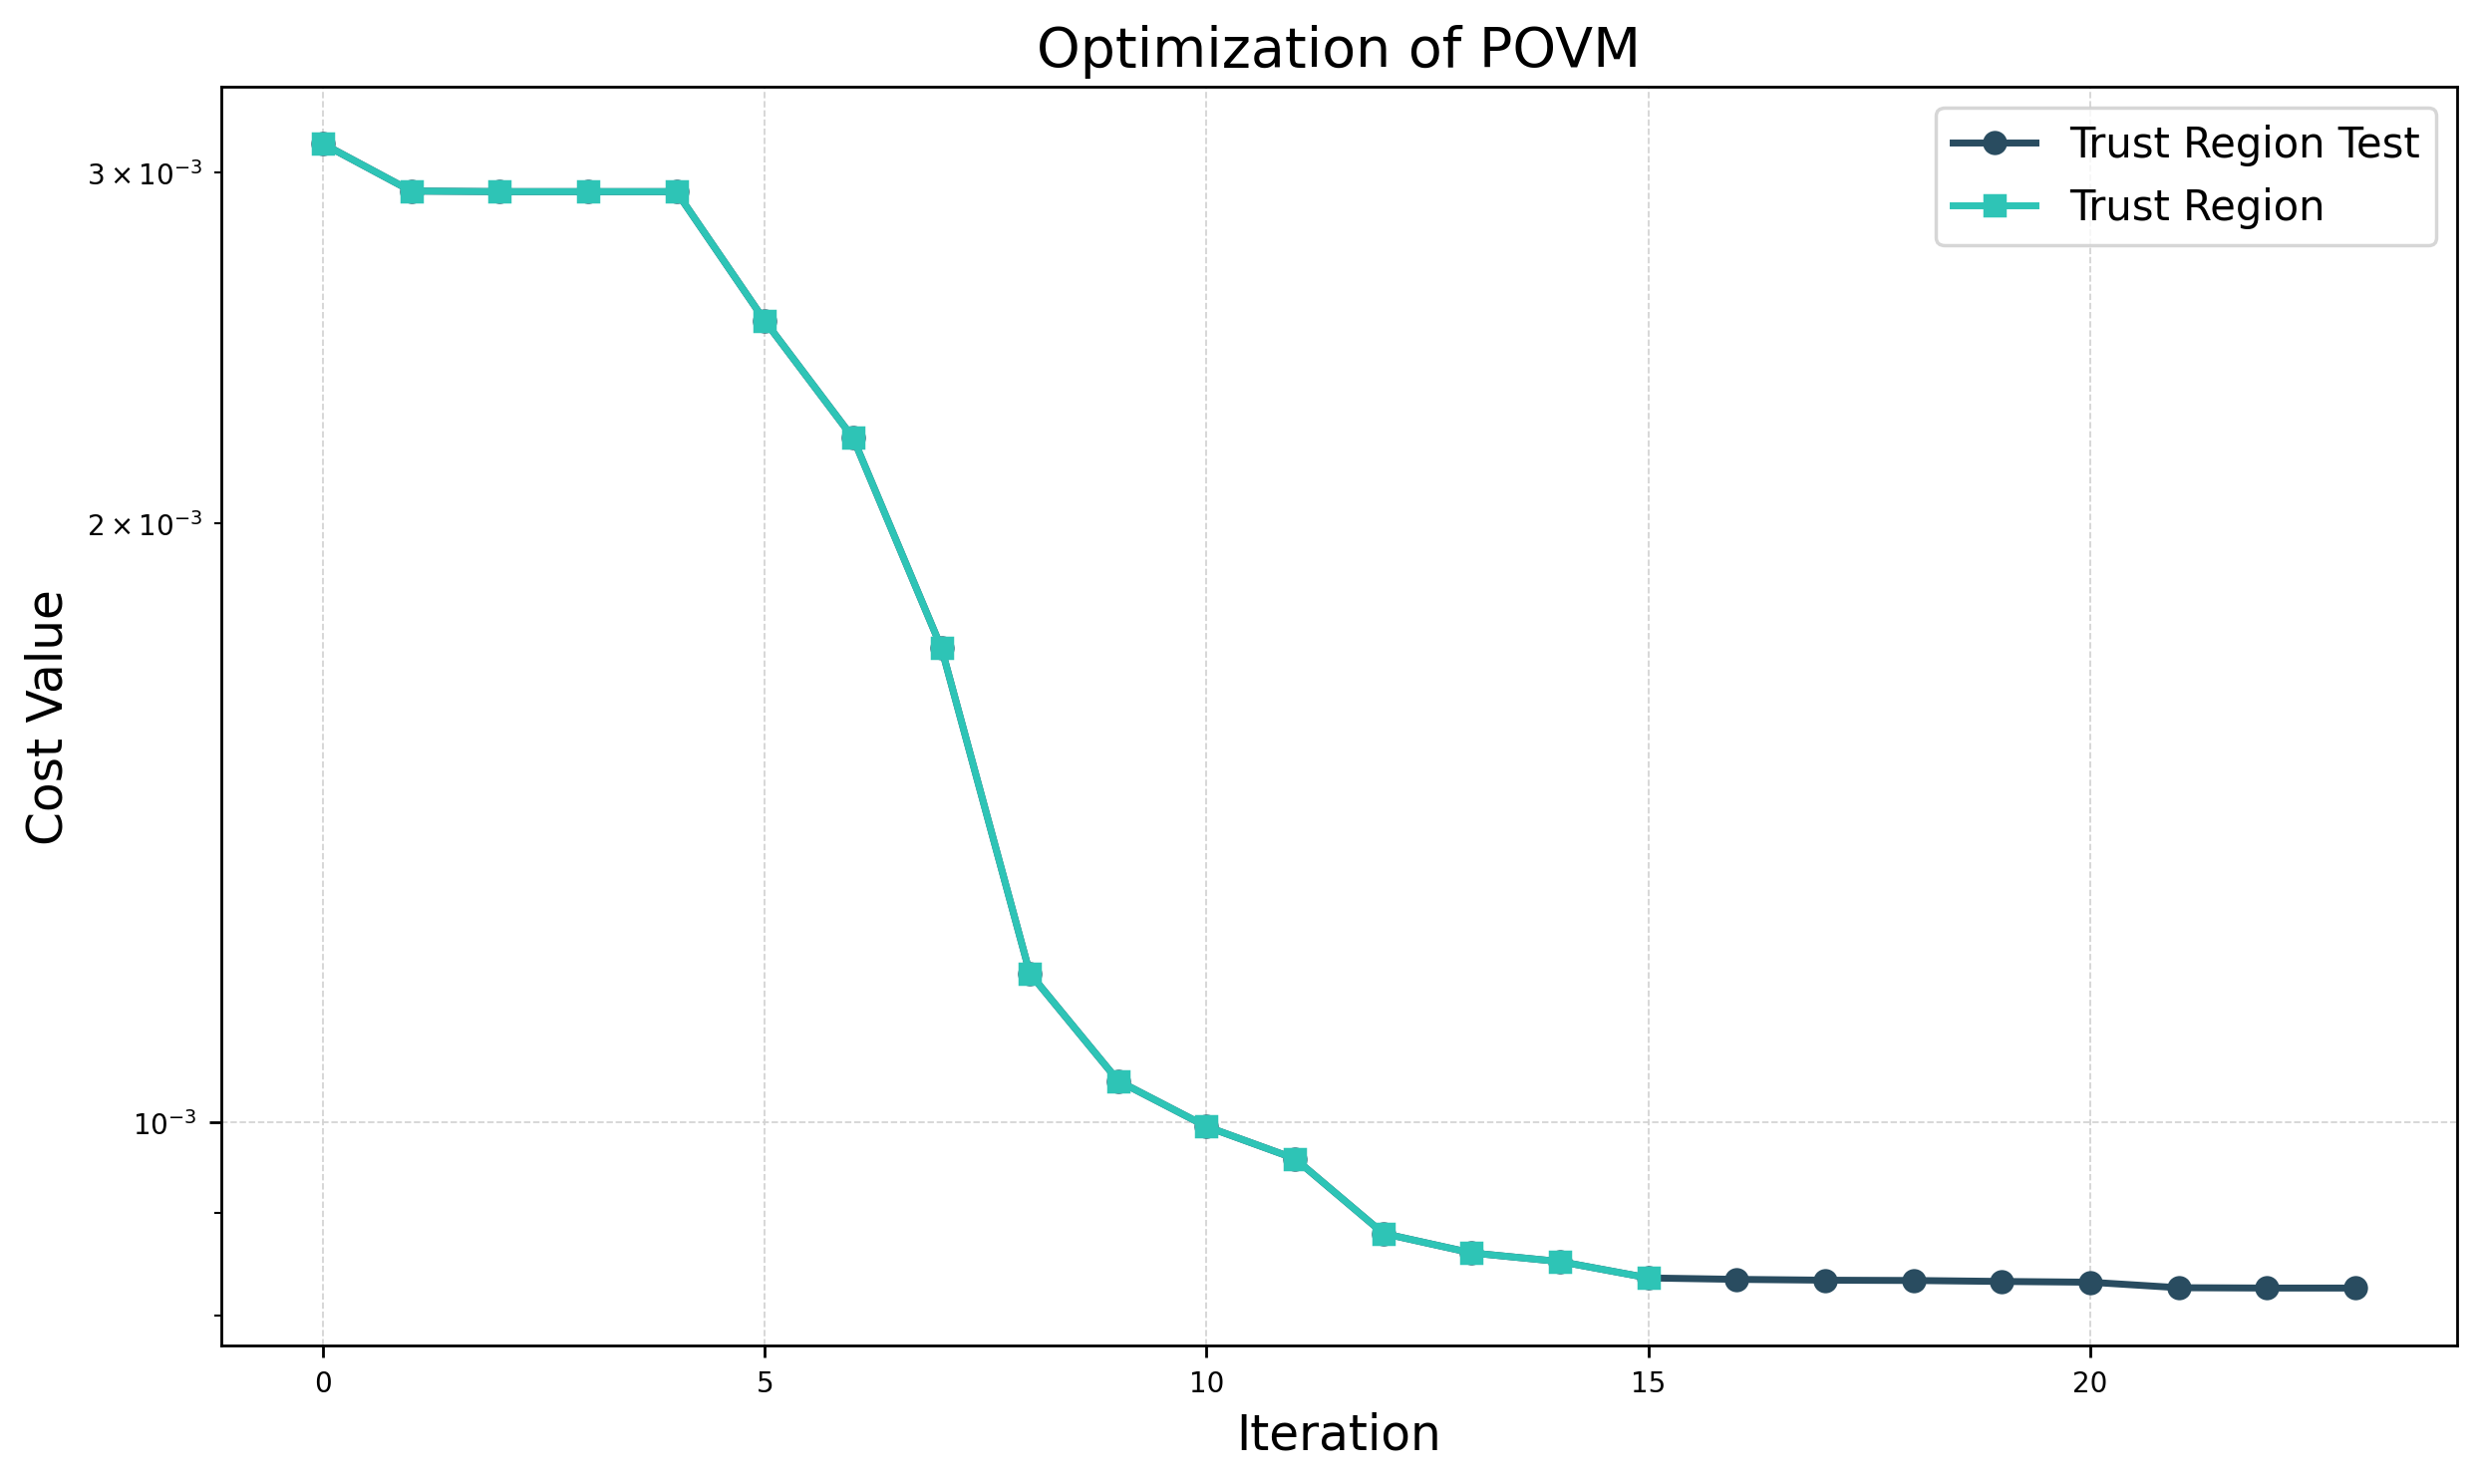

In [254]:
title = "Optimization of POVM"
cost_array_test = [cost_fx_optimized_test, cost_fx_optimized]
labels_test = ["Trust Region Test", "Trust Region", ]
plot_cost_function(cost_array=cost_array_test, title=title, labels=labels_test)

# Compare against other methods (POVM)

In [26]:
# We have to find a way to perform optimization only on the POVM elements.
def gradient_descent_povm(x_init:Tensor, cost_fn:Callable, init_step:float, num_iterations:int, cost_fn_kwargs:dict, optimize_step:bool=True, use_geodesic:bool=True, ls_max_iter:int=200, ls_method:str="COBYLA", metric="canonical", verbose:bool=True):
    """Perform gradient descent optimization on the POVM elements."""
    x_k = x_init
    step_k = init_step
    cost_k = cost_fn(x_k) 
    cost_fn_array = [cost_k]
    x_k_array = [x_k]
    
    kraus_tensor = cost_fn_kwargs["kraus_tensor"]
    state_psd = cost_fn_kwargs["state_psd"]
    indices_list = cost_fn_kwargs["indices_list"]
    prob_matrix = cost_fn_kwargs["prob_matrix"]
    
    print("Gradient Descent Optimization 🔋")
    for idx in range(num_iterations):
        print(f"Iteration {idx+1}/{num_iterations}, Cost function: {cost_k}, Step size: {step_k}")
        x_k, step_k = _update_tensor_via_gradient("povm", kraus_tensor=kraus_tensor, povm_psd=x_k, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix, ls_method=ls_method, ls_max_iter=ls_max_iter, optimize_step=optimize_step, initial_step=step_k, use_geodesic=use_geodesic, regularized=False, metric=metric, verbose=verbose)
    
        cost_k = cost_fn(x_k)
        cost_fn_array.append(cost_k)
        x_k_array.append(x_k)

    return x_k, jnp.array(x_k_array), jnp.array(cost_fn_array)

def sf_newton_povm(x_init:Tensor, cost_fn:Callable, num_iterations:int, cost_fn_kwargs:dict):
    """Perform saddle-free Newton optimization on the POVM elements.
    
    In this method:
    * line search method is performed by default.
    * Geodesic is used by default.
    * LS num iterations uses default by scipy `minimize`.
    * LS method is COBYLA by default.
    """
    x_k = x_init
    cost_k = cost_fn(x_k) 
    cost_fn_array = [cost_k]
    x_k_array = [x_k]
    
    kraus_tensor = cost_fn_kwargs["kraus_tensor"]
    state_psd = cost_fn_kwargs["state_psd"]
    indices_list = cost_fn_kwargs["indices_list"]
    prob_matrix = cost_fn_kwargs["prob_matrix"]

    print("Saddle-Free Newton Optimization 🚨")
    for idx in range(num_iterations):
        print(f"Iteration {idx+1}/{num_iterations}, Cost function: {cost_k},")
        x_k = update_povm_via_saddle_free_newton(
            kraus_tensor=kraus_tensor,
            povm_psd=x_k,
            state_psd=state_psd,
            indices_list=indices_list,
            prob_matrix=prob_matrix,
        )
        
        cost_k = cost_fn(x_k)
        cost_fn_array.append(cost_k)
        x_k_array.append(x_k)

    return x_k, jnp.array(x_k_array), jnp.array(cost_fn_array)

cost_fn_kwargs = {
    "kraus_tensor": kraus_tensor_init_jax,
    "state_psd": state_psd_init_jax,
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q_sampled
}

In [27]:
x_optimized_gds, x_array_optimized_gds, cost_fx_optimized_gds = gradient_descent_povm(
    x_init=x,
    cost_fn=cost_fn_povm,
    init_step=1.0,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs,
    metric="canonical",
    verbose=False,
)

Gradient Descent Optimization 🔋
Iteration 1/20, Cost function: 0.0031009132280137254, Step size: 1.0
Iteration 2/20, Cost function: 0.002966220180103963, Step size: [18.16450664]
Iteration 3/20, Cost function: 0.002940863173819487, Step size: [24.89664023]
Iteration 4/20, Cost function: 0.0029355537327170455, Step size: [18.69615664]
Iteration 5/20, Cost function: 0.0029343034728038305, Step size: [25.4059293]
Iteration 6/20, Cost function: 0.0029339946854865366, Step size: [19.01481602]
Iteration 7/20, Cost function: 0.002933912307435703, Step size: [25.97589766]
Iteration 8/20, Cost function: 0.002933889202467453, Step size: [19.37975039]
Iteration 9/20, Cost function: 0.0029338821688977717, Step size: [26.65831484]
Iteration 10/20, Cost function: 0.0029338799194512, Step size: [19.74738203]
Iteration 11/20, Cost function: 0.002933879147347835, Step size: [27.25822422]
Iteration 12/20, Cost function: 0.002933878872765272, Step size: [20.01613672]
Iteration 13/20, Cost function: 0.002

In [29]:
x_optimized_gds_euclidean, x_array_optimized_gds_euclidean, cost_fx_optimized_gds_euclidean = gradient_descent_povm(
    x_init=x,
    cost_fn=cost_fn_povm,
    init_step=1.0,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs,
    metric="euclidean",
    verbose=False,
)

Gradient Descent Optimization 🔋
Iteration 1/20, Cost function: 0.0031009132280137254, Step size: 1.0
Iteration 2/20, Cost function: 0.0029662201801000975, Step size: [36.32875742]
Iteration 3/20, Cost function: 0.002940863040963051, Step size: [49.79398945]
Iteration 4/20, Cost function: 0.002935553692764169, Step size: [37.3919457]
Iteration 5/20, Cost function: 0.0029343034572554437, Step size: [50.81254414]
Iteration 6/20, Cost function: 0.002933994681014391, Step size: [38.02964102]
Iteration 7/20, Cost function: 0.002933912306358618, Step size: [51.95141602]
Iteration 8/20, Cost function: 0.0029338892021156856, Step size: [38.76010977]
Iteration 9/20, Cost function: 0.002933882168575696, Step size: [53.31489727]
Iteration 10/20, Cost function: 0.0029338799187737068, Step size: [39.50034414]
Iteration 11/20, Cost function: 0.002933879145498764, Step size: [54.54701914]
Iteration 12/20, Cost function: 0.0029338788684211575, Step size: [40.18676758]
Iteration 13/20, Cost function: 0.

In [21]:
x_optimized_sfn, x_array_optimized_sfn, cost_fx_optimized_sfn = sf_newton_povm(
    x_init=x,
    cost_fn=cost_fn_povm,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs,
)

Saddle-Free Newton Optimization 🚨
Iteration 1/20, Cost function: 0.0031009132280137254,
Iteration 2/20, Cost function: 0.0029339601126951442,
Iteration 3/20, Cost function: 0.002933878722217012,
Iteration 4/20, Cost function: 0.0029338787074183964,
Iteration 5/20, Cost function: 0.0029338566772851653,
Iteration 6/20, Cost function: 0.001795921195274102,
Iteration 7/20, Cost function: 0.0010606259770956673,
Iteration 8/20, Cost function: 0.000873066182597035,
Iteration 9/20, Cost function: 0.0008387255155756919,
Iteration 10/20, Cost function: 0.0008335315744218549,
Iteration 11/20, Cost function: 0.0008328322639355444,
Iteration 12/20, Cost function: 0.0008324400847758148,
Iteration 13/20, Cost function: 0.0008292458110599685,
Iteration 14/20, Cost function: 0.0008257948054028455,
Iteration 15/20, Cost function: 0.0008254654951865638,
Iteration 16/20, Cost function: 0.0008254318475835391,
Iteration 17/20, Cost function: 0.0008254281171680566,
Iteration 18/20, Cost function: 0.000825427

## Visualize

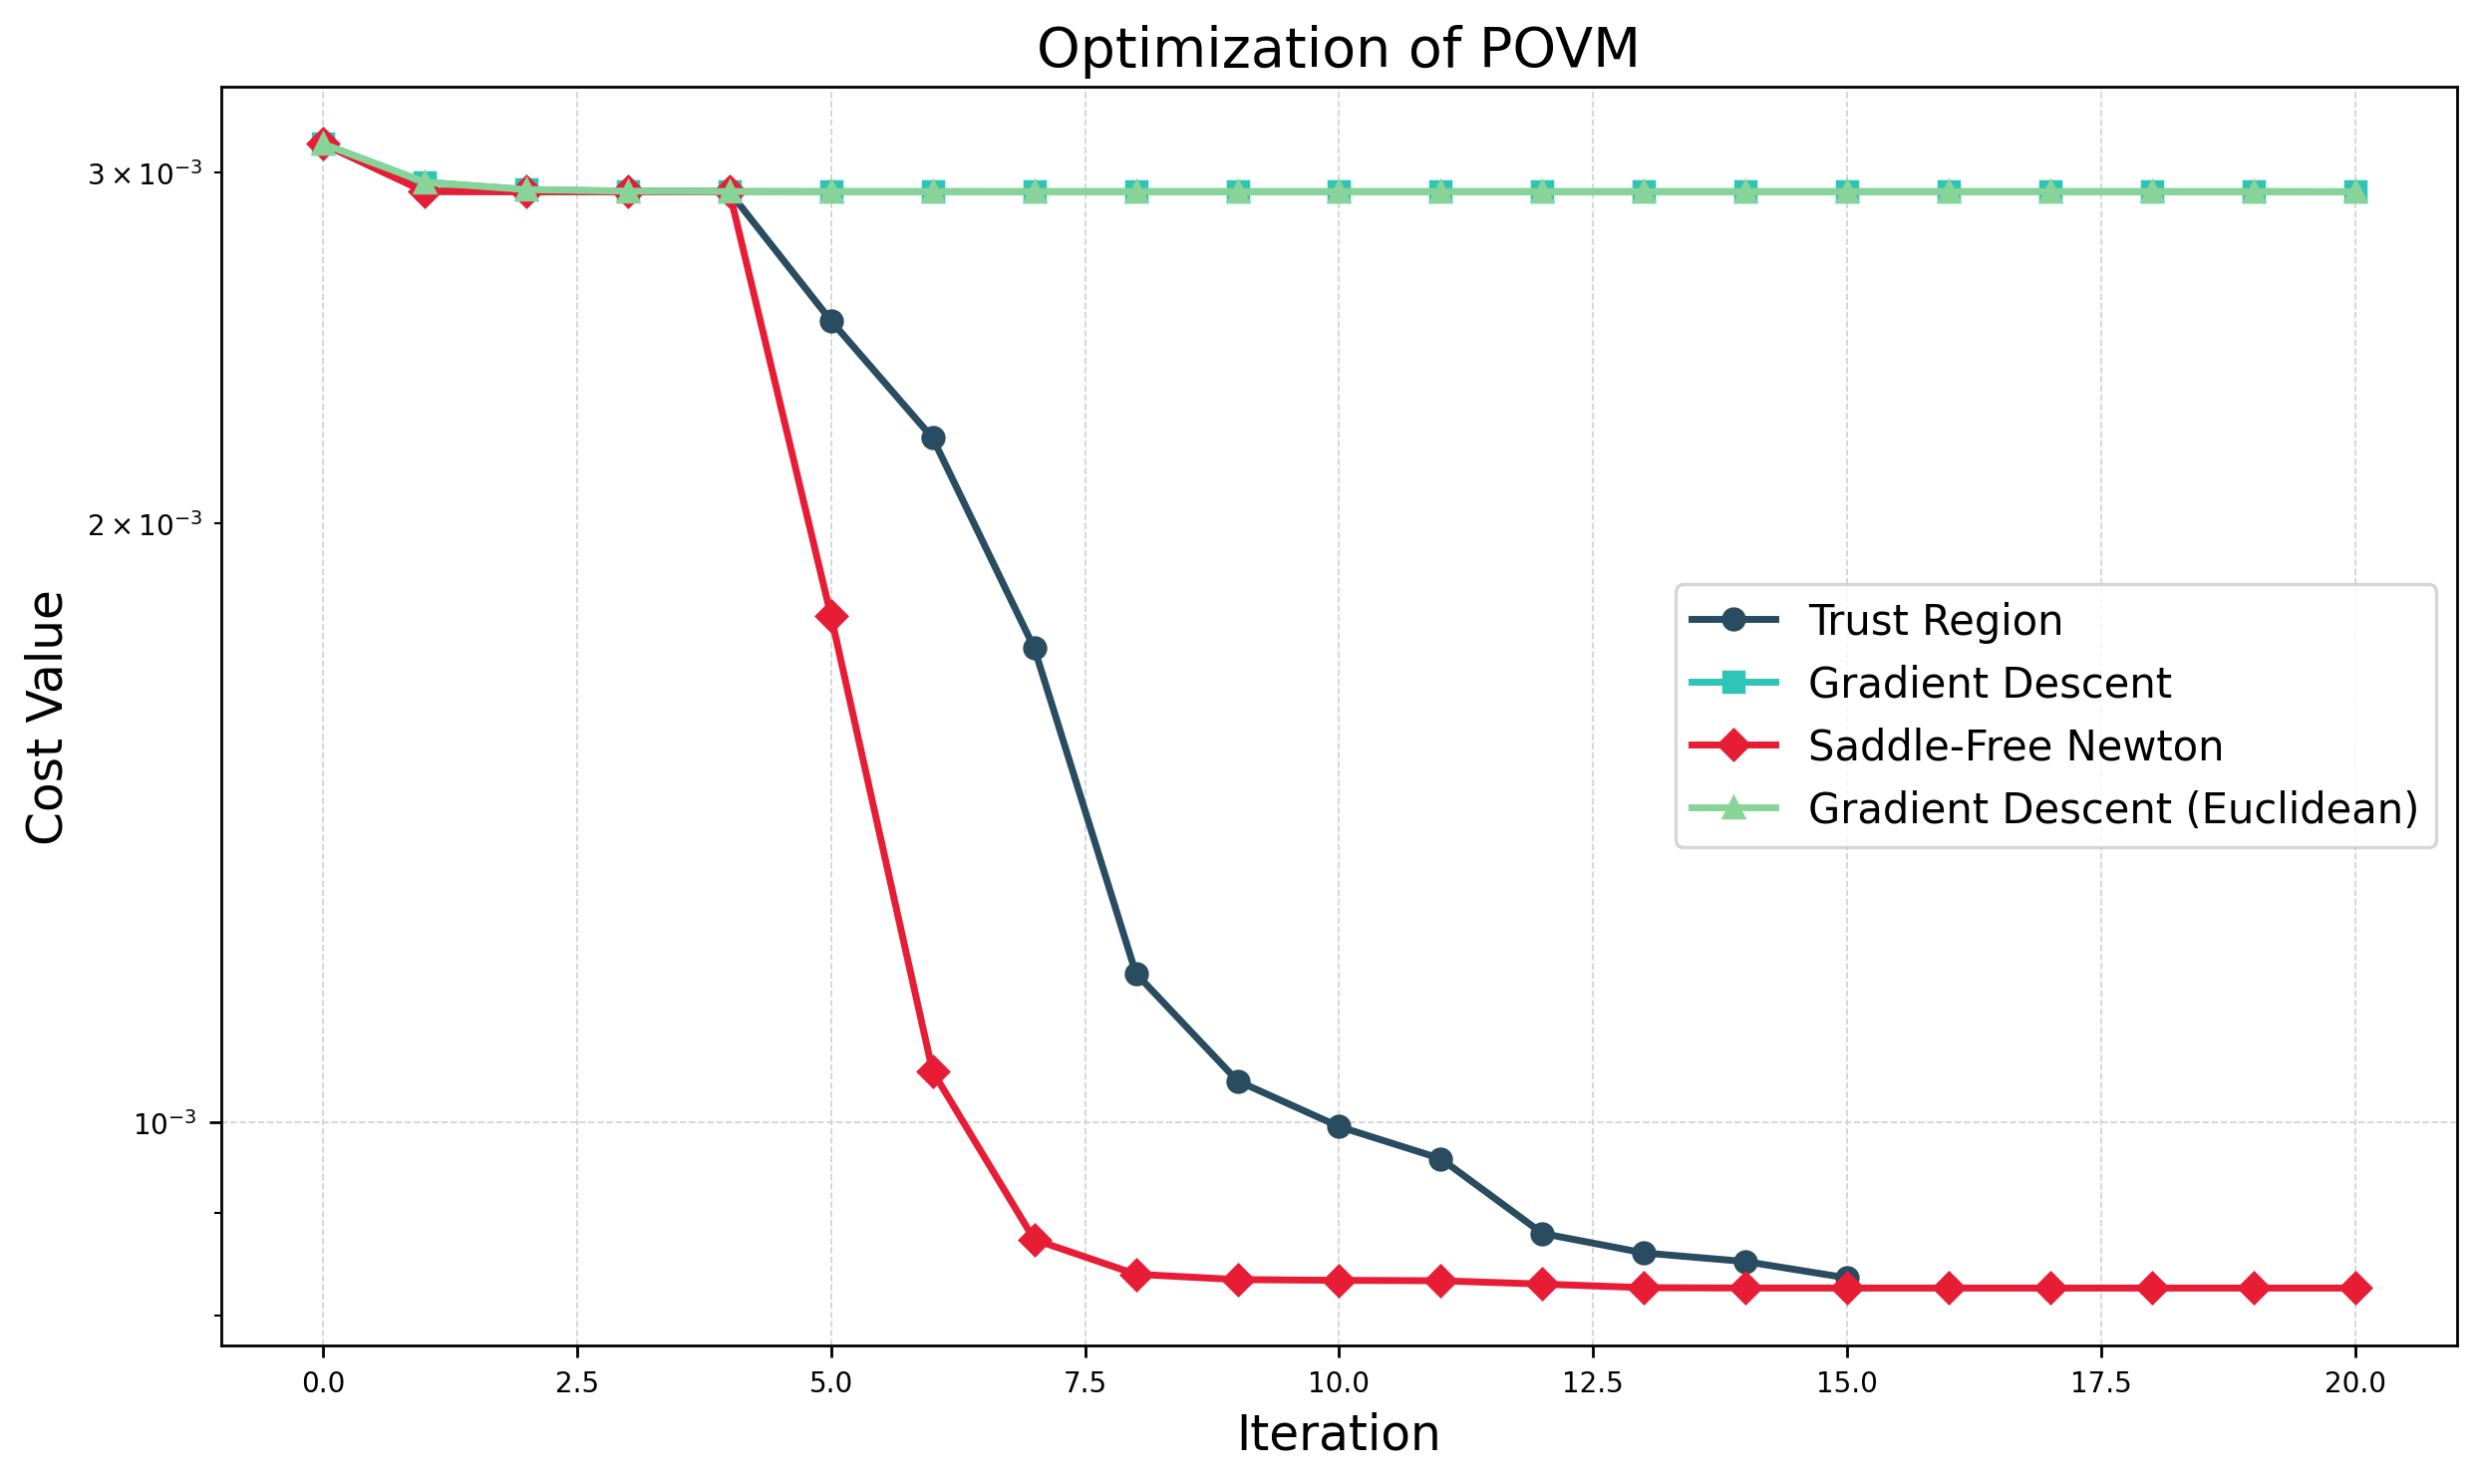

In [80]:
title = "Optimization of POVM"
cost_array = [cost_fx_optimized, cost_fx_optimized_gds, cost_fx_optimized_sfn, cost_fx_optimized_gds_euclidean]
labels = ["Trust Region", "Gradient Descent", "Saddle-Free Newton", "Gradient Descent (Euclidean)"]
plot_cost_function(cost_array=cost_array, title=title, labels=labels)

In [24]:
# Final cost functions:
xk_optimized_array = [x_optimized, x_optimized_gds, x_optimized_sfn]
final_cost = [cost_fn_povm(xk) for xk in xk_optimized_array]
print("Final costs:", final_cost)

initial_cost_array = [array[0] for array in cost_array]
ratios = [initial_value / final_value for initial_value, final_value in zip(initial_cost_array, final_cost)]
print("Ratios:", ratios)

Final costs: [Array(0.00083514, dtype=float64), Array(0.00293388, dtype=float64), Array(0.00082543, dtype=float64)]
Ratios: [Array(3.71302769, dtype=float64), Array(1.05693301, dtype=float64), Array(3.75673594, dtype=float64)]


Ratio: 4.519155607356383


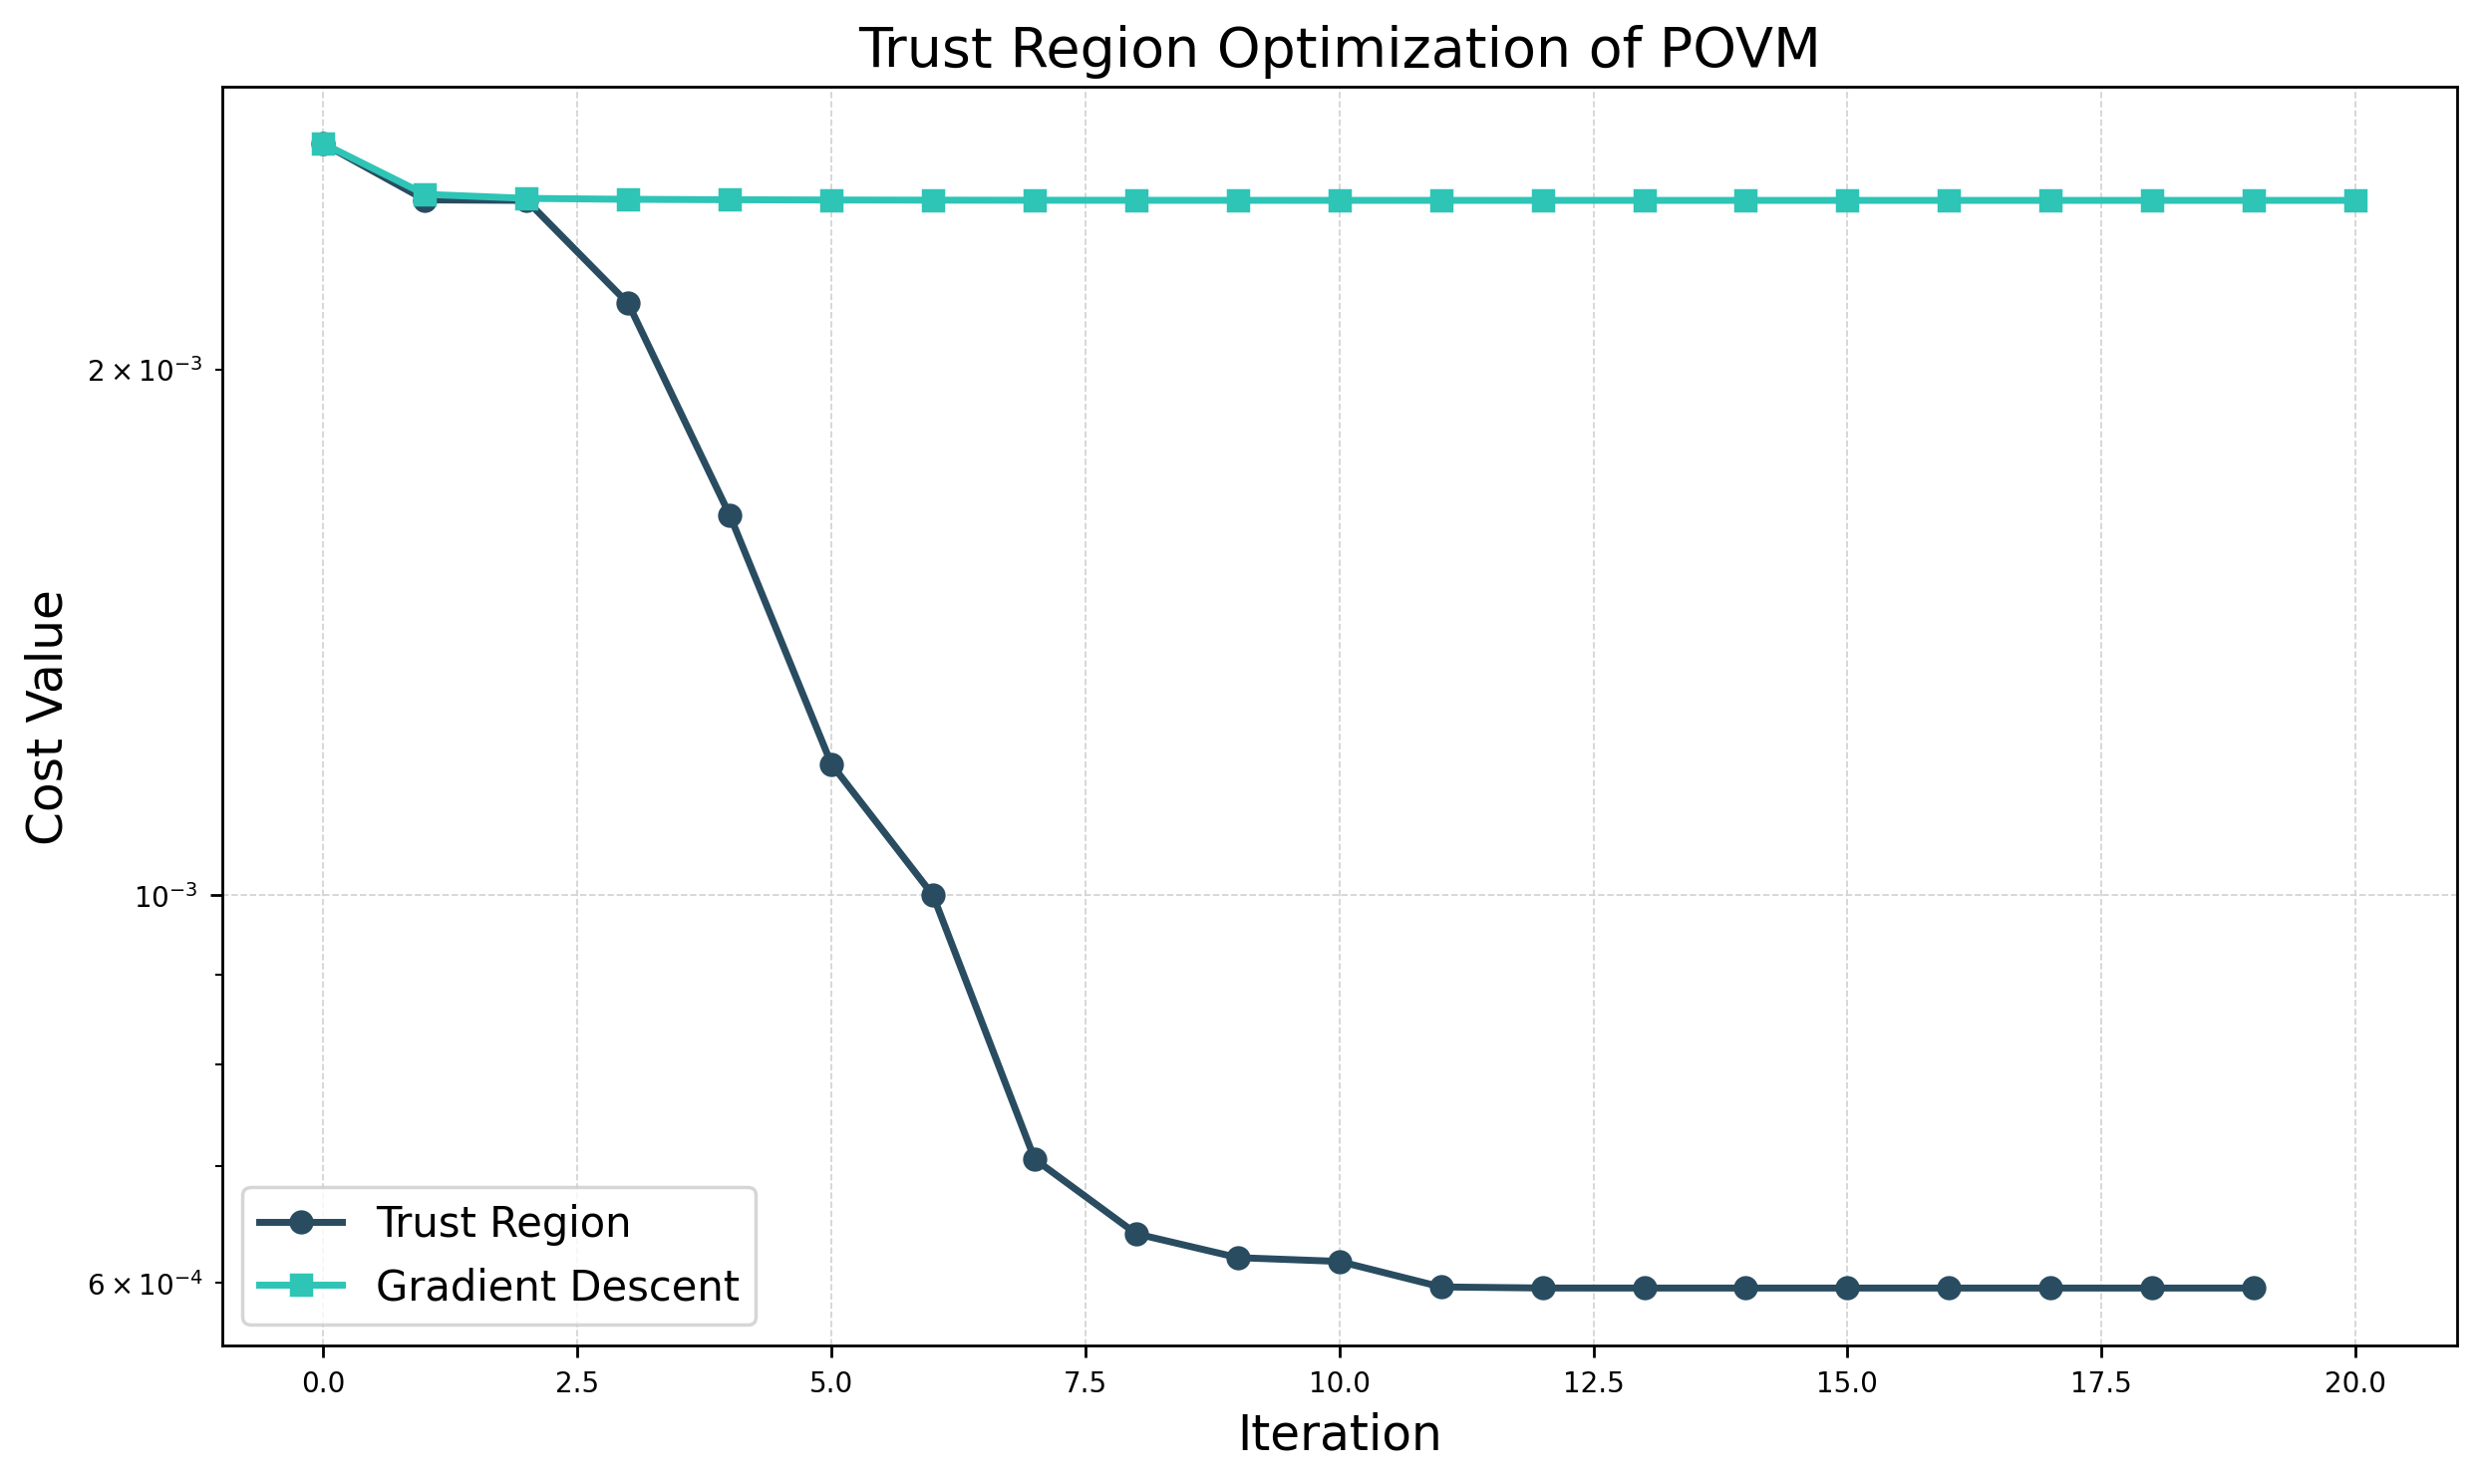

In [ ]:
# From previous run.
# print(f"Ratio: {cost_fx_optimized[0]/cost_fx_optimized[-1]}")
# plot_cost_function(cost_array=cost_array, title=title, labels=labels)

# Timing performance (POVM)

In [ ]:
# Time the performance of one SFN iteration.
%timeit update_povm_via_saddle_free_newton(povm_psd=x, **cost_fn_kwargs)

684 ms ± 15.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# Time the performance of the GDS.
%timeit _update_tensor_via_gradient(operator_type="povm", povm_psd=x, verbose=False, **cost_fn_kwargs)

241 ms ± 9.63 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# Time individual elements of the TR algorithm.
%timeit compute_quality_quotient(x=x, update_direction=gradient_init, cost_function=cost_fn_povm, x_next=x, n=n, p=p)

65.9 ms ± 2.08 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit riemannian_gradient_function(x)

42.8 ms ± 302 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit rhessian_vector_fn(x, gradient_init)

57.5 ms ± 908 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit compute_step_size(z=gradient_init_matrix, delta=gradient_init_matrix, x=x_matrix, radius=radius_init, metric=metric)

782 μs ± 17.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [324]:
sfn_avg, sfn_std = (684e-3, 15.4e-3)
gds_avg, gds_std = (241e-3, 9.63e-3)

tr_times = [(65.9e-3, 2.08e-3), (42.8e-3, 302e-6)]  # (mean, std) for quotient, gradient
tr_main_avg, tr_main_std = average_and_error_of_sum(*tr_times)
hz_avg, hz_std = (57.5e-3, 908e-6)
# How many times can we repeat the hessian-vec-time until the TR time matches the SFN time?
hz_repeats = (sfn_avg - tr_main_avg) / hz_avg
print(f"Estimated number of Hessian-vector products per TR iteration: {hz_repeats:.1f}")
# Assume we perform half of those repeats in average.
hz_repeats_estimation = hz_repeats//2
hz_scaled_avg, hz_scaled_std = average_and_error_times_scalar((hz_avg, hz_std), hz_repeats_estimation)
# Total estimated time for TR iteration.
tr_total_avg, tr_total_std = average_and_error_of_sum((tr_main_avg, tr_main_std), (hz_scaled_avg, hz_scaled_std))
print(f"Trust Region average time: {tr_total_avg*1e3:.2f} ms ± {tr_total_std*1e3:.2f} ms")

Estimated number of Hessian-vector products per TR iteration: 10.0
Trust Region average time: 396.20 ms ± 5.00 ms


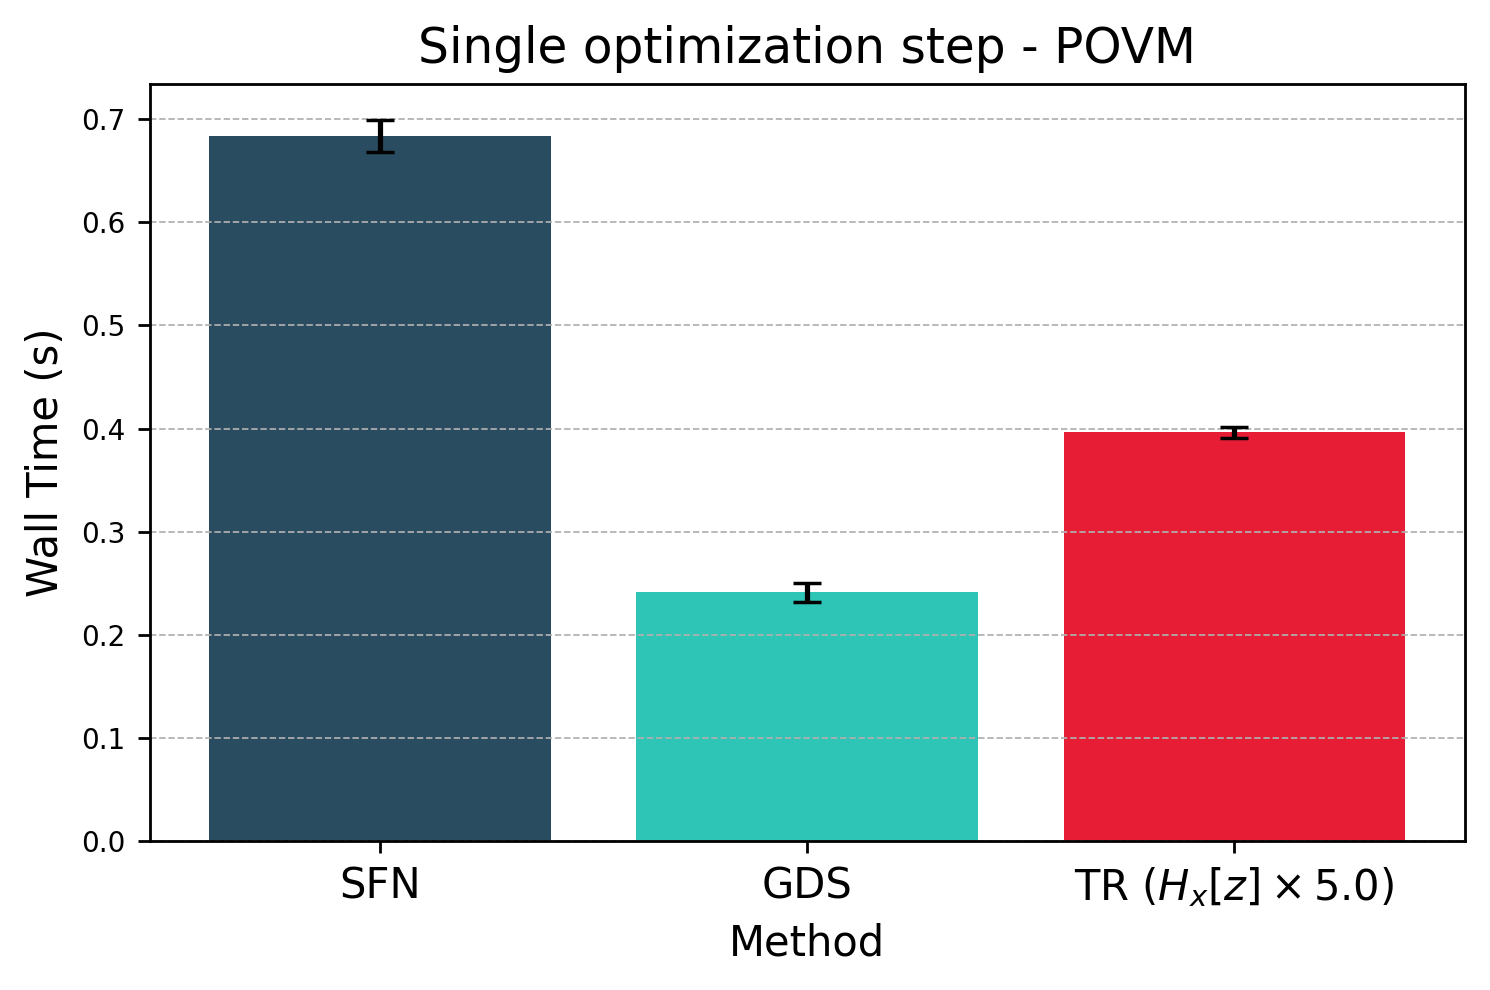

In [341]:
times_dict = {
    "SFN": (sfn_avg, sfn_std), # seconds
    "GDS": (gds_avg, gds_std), # seconds
    rf"TR ($H_x[z] \times {hz_repeats_estimation}$)": (tr_total_avg, tr_total_std) # seconds
}

plot_bars_with_error(
    data=times_dict,
    title="Single optimization step - POVM",
    ylabel="Wall Time (s)",
    xlabel="Method",
)

# Repeat procedure for state

In [ ]:
cost_fn_state = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_init_jax,
    state_psd=x,
    povm_psd=povm_psd_init_jax, # to see if we can keep decreasing the cost function
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    jit=True
)

cost_fn_state(state_psd_init_jax)

Array(0.00310091, dtype=float64)

In [ ]:
x_state_optimized, x_state_array_optimized, cost_state_fx_optimized = run_trust_region_optimization(
    x_init=state_psd_init_jax,
    cost_function=cost_fn_state,
    radius_init=radius_init,
    num_iterations=num_iterations_tr,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="state",
    metric=metric,
    num_iterations_cg=num_iterations_cg,
    theta_cg=None,
    kappa_cg=kappa,
    tol_grad=tol_grad,
    verbose_cg=True,
    verbose=True,
)

TR started for operator: state 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 7.644320e-03. Radius: 1.00e-01
TCG finished after: 7/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 1. f(x): 2.905781e-03. |r∇f(x)|: 1.056807e-03. Radius: 2.00e-01
TCG finished after: 5/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 2.751195e-03. |r∇f(x)|: 9.763510e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:104: RuntimeWarning: encountered t < 0: -73.4516624570147
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 2/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 3. f(x): 1.880484e-03. |r∇f(x)|: 6.658300e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:104: RuntimeWarning: encountered t < 0: -67.3045218715263
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 3/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 4. f(x): 1.803161e-03. |r∇f(x)|: 7.068000e-03. Radius: 5.00e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:104: RuntimeWarning: encountered t < 0: -1.6767165656087815
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 1/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 5. f(x): 1.582245e-03. |r∇f(x)|: 2.157204e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:98: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


TCG finished after: 14/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 6. f(x): 1.546005e-03. |r∇f(x)|: 4.321681e-04. Radius: 2.00e-01
TCG finished after: 16/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 7. f(x): 1.546005e-03. |r∇f(x)|: 4.321681e-04. Radius: 5.00e-02
TCG finished after: 16/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 8. f(x): 1.544755e-03. |r∇f(x)|: 1.001797e-04. Radius: 1.00e-01
TCG finished after: 15/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 9. f(x): 1.544755e-03. |r∇f(x)|: 1.001797e-04. Radius: 2.50e-02
TCG finished after: 15/20 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 10. f(x): 1.544646e-03. |r∇f(x)|: 5.051088e-05. Rad

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:98: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


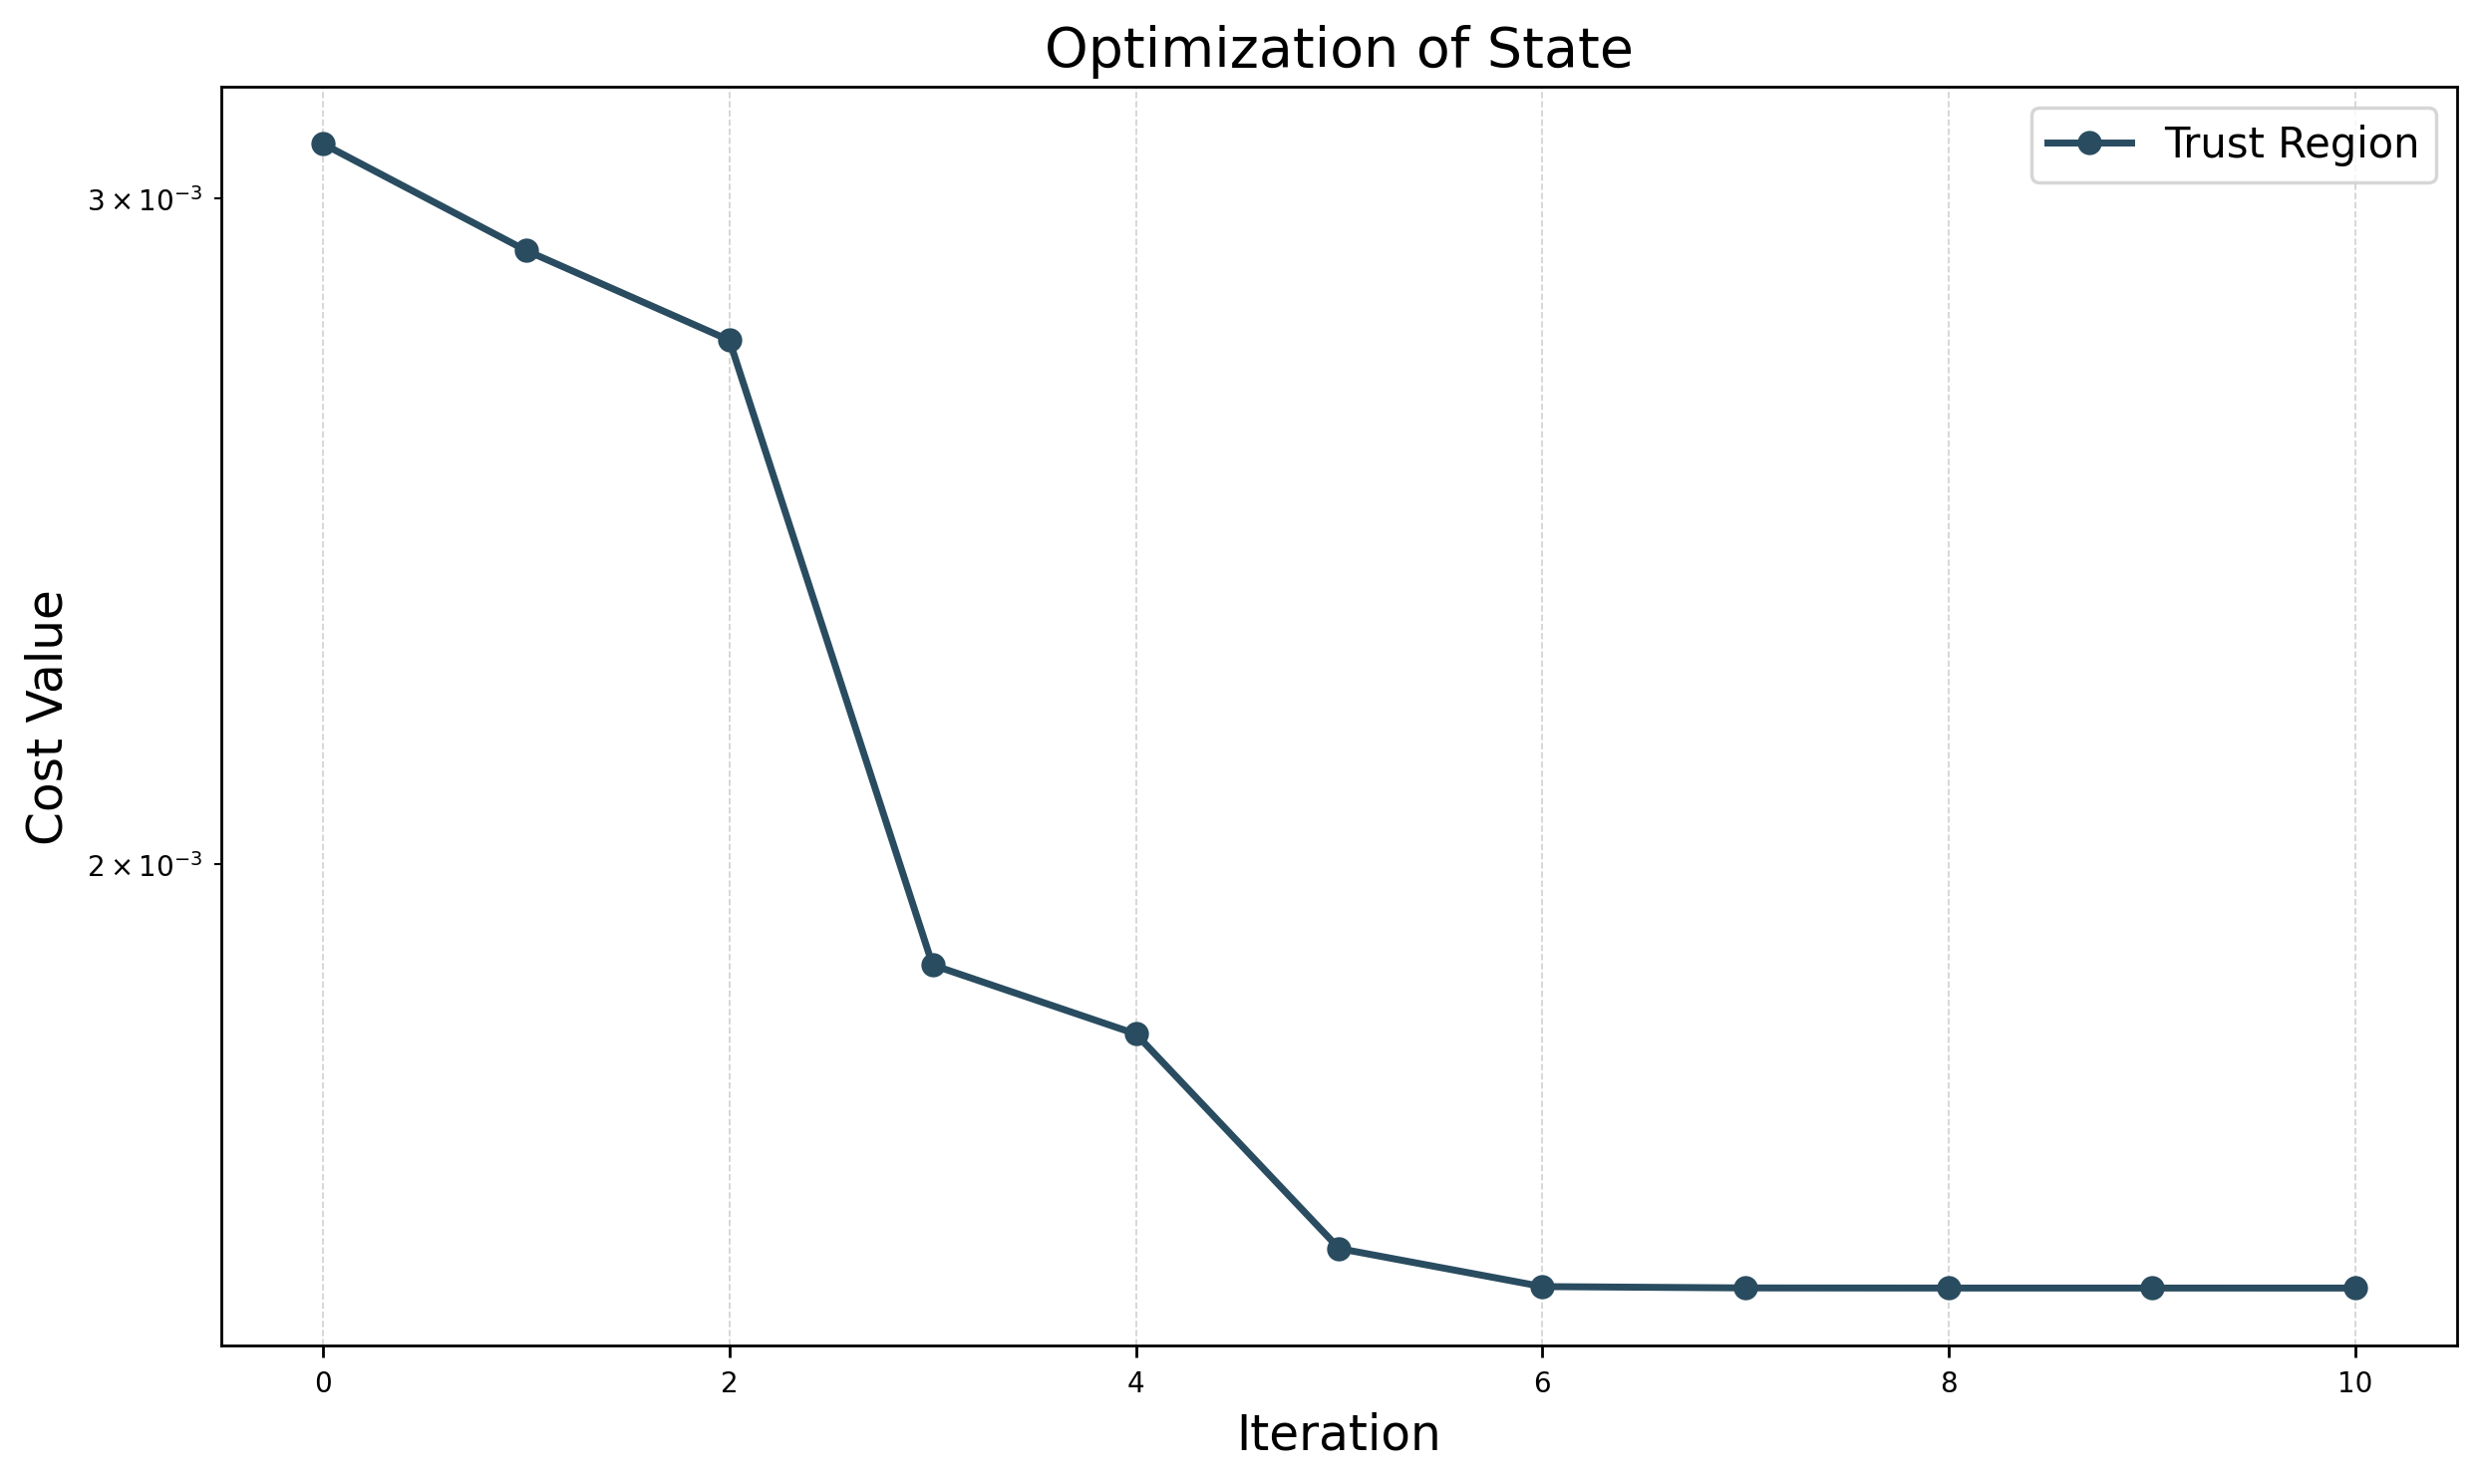

In [174]:
title = "Optimization of State"
cost_array_state = [cost_state_fx_optimized]
labels_state = ["Trust Region"]
plot_cost_function(cost_array=cost_array_state, title=title, labels=labels_state)

# Now test with the Kraus operators

In [14]:
cost_fn_kraus = lambda x: cost_function_jax_mps(
    kraus_tensor=x,
    state_psd=state_psd_init_jax,
    povm_psd=povm_psd_init_jax,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    jit=True
)

cost_fn_kraus(kraus_tensor_init_jax)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


Array(0.00314801, dtype=float64)

In [17]:
x_kraus = kraus_tensor_init_jax
metric = "canonical"
rgrad_kraus_test = riemannian_gradient_fn(x=x_kraus, cost_fn=cost_fn_kraus, operator_type="kraus", metric=metric)
rgrad_kraus_test.shape

(7, 16, 4, 4)

## Tests

In [267]:
# Check if this works with POVM tensors
povm_iso_test, grad_iso_test = tensors_to_isometries(povm_psd_init_jax, gradient_init, operator_type="povm")
print(povm_iso_test.shape, grad_iso_test.shape)

kraus_iso_test, grad_kraus_test = tensors_to_isometries(kraus_tensor_init_jax, rgrad_kraus_test, operator_type="kraus")
print(kraus_iso_test.shape, grad_kraus_test.shape)

print(all(is_isometry(iso) for iso in kraus_iso_test))

(16, 4) (16, 4)
(7, 64, 4) (7, 64, 4)
True


In [268]:
rhessian_vect_tensor_test1 = rhessian_vector_fn(x=x, z=z_random_tensor)

In [269]:
rhessian_vect_tensor_test_2 = rhessian_vector_fn(x=x, z=z_random_tensor)

In [270]:
jnp.allclose(rhessian_vect_tensor_test1, rhessian_vect_tensor_test_2)

Array(True, dtype=bool)

In [271]:
# Testing that the new changes on random_random_vector and project_onto_tangent_space work with batch dimensions
z_random_2 = random_tangent_vector(x_matrix, seed=42)
jnp.allclose(z_random_2, z_random)

Array(True, dtype=bool)

In [272]:

(x_kraus_matrix,) = tensors_to_isometries(x_kraus, operator_type="kraus")
z_kraus = random_tangent_vector(x_kraus_matrix, seed=42)
z_kraus_tensor = isometry_to_tensor(z_kraus, x_kraus.shape)

rhess_vec_kraus = riemannian_hessian_vector_fn(x=x_kraus, tangent_vector=z_kraus_tensor, cost_fn=cost_fn_kraus, operator_type="kraus", metric=metric)

rhess_vec_kraus.shape

(7, 16, 4, 4)

In [273]:
# Testing the model works with the batch implementation. First the original one
first_order, second_order = compute_approx_terms_from_tensors(x=x, z=z_random_tensor, cost_function=cost_fn_povm, n=n, p=p)
first_order, second_order

(Array(0.00154512, dtype=float64), Array(-0.36287923, dtype=float64))

In [274]:
# Now try with the batch implementation
    
def _compute_second_order_term_test(x:Tensor, z:Tensor, gradient_conjugated:Tensor, hessian_z:Tensor, n:int, p:int)->float:    
    gradient_mtrx, x_mtrx, z_mtrx = tensors_to_isometries(gradient_conjugated, x, z, n=n, p=p)  # Dx = 2df/dx
    extra_factor = z_mtrx.conj() @ transpose(x_mtrx) @ gradient_mtrx
    extra_factor_tensor = isometry_to_tensor(extra_factor, x.shape)
    # (1/2)<z, Hx[z] - z* x.T 2df/dx>e with <z1, z2>e = Re(Tr(z1.T z2))
    return 0.5 * (compute_euclidean_inner_product_tensors(z, hessian_z - extra_factor_tensor, adjoint=False))

def compute_terms_test(x, z, cost_function, n, p):
    gradient_function = automatic_gradient(cost_function)
    gradient_conjugated, hessian_z = hvp(function=gradient_function, x=x, z=z) # 2df/dx, 2(Hxx dx + Hx*x dx*)
    first_order_term = _compute_first_order_term(z, gradient_conjugated)
    second_order_term = _compute_second_order_term_test(x=x, z=z, gradient_conjugated=gradient_conjugated, hessian_z=hessian_z, n=n, p=p)
    return first_order_term, second_order_term

first_order_test, second_order_test = compute_terms_test(x=x, z=z_random_tensor, cost_function=cost_fn_povm, n=n, p=p)
first_order_test, second_order_test

(Array(0.00154512, dtype=float64), Array(-0.36287923, dtype=float64))

In [275]:
n_kraus, p_kraus = get_isometry_dimensions_from_tensor(x_kraus, operator_type="kraus")
first_order_kraus, second_order_kraus = compute_approx_terms_from_tensors(x=x_kraus, z=z_kraus_tensor, cost_function=cost_fn_kraus, n=n_kraus, p=p_kraus)
first_order_kraus, second_order_kraus

(Array(0.02987065, dtype=float64), Array(-12.72610066, dtype=float64))

In [276]:
riemannian_metric_from_tensors(n=n, p=p, x=x, z1=z_random_tensor, z2=z_random_tensor, metric=metric)

Array(111.25812349, dtype=float64)

In [277]:
riemannian_metric_from_tensors(n=n_kraus, p=p_kraus, x=x_kraus, z1=z_kraus_tensor, z2=z_kraus_tensor, metric=metric)

Array(3359.28873426, dtype=float64)

## Optimize

In [ ]:
x_kraus_optimized, x_kraus_array_optimized, cost_kraus_fx_optimized = run_trust_region_optimization(
    x_init=kraus_tensor_init_jax,
    cost_function=cost_fn_kraus,
    radius_init=radius_init,
    num_iterations=num_iterations_tr,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="kraus",
    metric=metric,
    num_iterations_cg=num_iterations_cg,
    theta_cg=None,
    kappa_cg=kappa,
    tol_grad=tol_grad,
    verbose_cg=True,
    verbose=True,
)

TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 1.978419e-02. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -5.122143273220263
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 3/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 2.198665e-03. |r∇f(x)|: 8.830160e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -9.048625583881503
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 3/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 1.570311e-03. |r∇f(x)|: 1.085518e-02. Radius: 2.00e-01


...

TCG finished after: 4/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 5. f(x): 6.205773e-04. |r∇f(x)|: 3.545422e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -4.008222463946021
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 5/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 6. f(x): 4.311388e-04. |r∇f(x)|: 4.301622e-03. Radius: 4.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -7.640553823315259
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 12/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 7. f(x): 2.967154e-04. |r∇f(x)|: 3.284253e-03. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 8. f(x): 1.196518e-04. |r∇f(x)|: 6.675599e-04. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 9. f(x): 9.405136e-05. |r∇f(x)|: 9.102707e-04. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 10. f(x): 7.767220e-05. |r∇f(x)|: 1.738215e-04. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 11. f(x): 7.377016e-05. |r∇f(x)|: 4.131439e-04. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iteratio

In [ ]:
x_kraus_optimized_euc, x_kraus_array_optimized_euc, cost_kraus_fx_optimized_euc = run_trust_region_optimization(
    x_init=kraus_tensor_init_jax,
    cost_function=cost_fn_kraus,
    radius_init=radius_init,
    num_iterations=num_iterations_tr,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="kraus",
    metric="euclidean",
    num_iterations_cg=num_iterations_cg,
    theta_cg=None,
    kappa_cg=kappa,
    tol_grad=tol_grad,
    verbose_cg=True,
    verbose=True,
)

TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 1.420331e-02. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -4.149521217178778
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 2/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 2.341797e-03. |r∇f(x)|: 8.917080e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -4.669481248135599
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 2/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 1.654349e-03. |r∇f(x)|: 1.029824e-02. Radius: 4.00e-01


...

TCG finished after: 17/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 5. f(x): 3.755508e-04. |r∇f(x)|: 4.017106e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -12.48350868161731
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 9/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 6. f(x): 1.737717e-04. |r∇f(x)|: 9.752343e-04. Radius: 4.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -6.695698216598164
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 14/20 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 7. f(x): 1.514989e-04. |r∇f(x)|: 1.876276e-03. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 8. f(x): 8.426031e-05. |r∇f(x)|: 2.316645e-04. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 9. f(x): 7.896621e-05. |r∇f(x)|: 6.277059e-04. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 10. f(x): 7.060536e-05. |r∇f(x)|: 5.949158e-05. Radius: 4.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 11. f(x): 7.017857e-05. |r∇f(x)|: 3.552926e-04. Radius: 1.00e-01
TCG finished after: 20/20 iters. 
 Reason: Max iteratio

In [ ]:
x_kraus_optimized_2, x_kraus_array_optimized_2, cost_kraus_fx_optimized_2 = run_trust_region_optimization(
    x_init=kraus_tensor_init_jax,
    cost_function=cost_fn_kraus,
    radius_init=radius_init,
    num_iterations=num_iterations_tr,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="kraus",
    metric=metric,
    num_iterations_cg=num_iterations_cg * 2,
    theta_cg=None,
    kappa_cg=kappa,
    tol_grad=tol_grad,
    verbose_cg=True,
    verbose=True,
)

TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 1.978419e-02. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -5.122143273220263
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 3/40 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 2.198665e-03. |r∇f(x)|: 8.830160e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -9.048625583881503
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 3/40 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 1.570311e-03. |r∇f(x)|: 1.085518e-02. Radius: 2.00e-01


...

TCG finished after: 26/40 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 9. f(x): 1.825140e-04. |r∇f(x)|: 2.302237e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -5.0992067739222255
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 10/40 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 10. f(x): 1.028323e-04. |r∇f(x)|: 4.133956e-04. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:106: RuntimeWarning: encountered t < 0: -5.812887966352364
  Compute the two solutions of the quadratic equation x^2 + 2 p x + q == 0.


TCG finished after: 18/40 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 11. f(x): 8.463474e-05. |r∇f(x)|: 5.809114e-04. Radius: 4.00e-01
TCG finished after: 40/40 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 12. f(x): 7.357610e-05. |r∇f(x)|: 1.508542e-04. Radius: 4.00e-01
TCG finished after: 40/40 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 13. f(x): 7.050937e-05. |r∇f(x)|: 3.458158e-04. Radius: 4.00e-01
TCG finished after: 40/40 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 14. f(x): 6.814147e-05. |r∇f(x)|: 4.113344e-05. Radius: 4.00e-01
TCG finished after: 40/40 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 15. f(x): 6.763403e-05. |r∇f(x)|: 1.218119e-04. Radius: 4.00e-01
TCG finished after: 40/40 iters. 
 Reason: Max itera

# Compare other methods for Kraus

In [21]:
# We have to find a way to perform optimization only on the POVM elements.
def gradient_descent_kraus(x_init:Tensor, cost_fn:Callable, init_step:float, num_iterations:int, cost_fn_kwargs:dict, optimize_step:bool=True, use_geodesic:bool=True, ls_max_iter:int=200, ls_method:str="COBYLA", metric="canonical", verbose:bool=True):
    """Perform gradient descent optimization on the Kraus operators."""
    x_k = x_init
    step_k = init_step
    cost_k = cost_fn(x_k) 
    cost_fn_array = [cost_k]
    x_k_array = [x_k]
    
    povm_psd = cost_fn_kwargs["povm_psd"]
    state_psd = cost_fn_kwargs["state_psd"]
    indices_list = cost_fn_kwargs["indices_list"]
    prob_matrix = cost_fn_kwargs["prob_matrix"]
    
    print("Gradient Descent Optimization 🔋")
    for idx in range(num_iterations):
        print(f"Iteration {idx+1}/{num_iterations}, Cost function: {cost_k}, Step size: {step_k}")
        x_k, step_k = _update_tensor_via_gradient("kraus", kraus_tensor=x_k, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix, ls_method=ls_method, ls_max_iter=ls_max_iter, optimize_step=optimize_step, initial_step=step_k, use_geodesic=use_geodesic, regularized=False, metric=metric, verbose=verbose)
    
        cost_k = cost_fn(x_k)
        cost_fn_array.append(cost_k)
        x_k_array.append(x_k)

    return x_k, jnp.array(x_k_array), jnp.array(cost_fn_array)

def sf_newton_kraus(x_init:Tensor, cost_fn:Callable, num_iterations:int, cost_fn_kwargs:dict):
    """Perform saddle-free Newton optimization on the Kraus operators.
    
    In this method:
    * line search method is performed by default.
    * Geodesic is used by default.
    * LS num iterations uses default by scipy `minimize`.
    * LS method is COBYLA by default.
    """
    x_k = x_init
    cost_k = cost_fn(x_k) 
    cost_fn_array = [cost_k]
    x_k_array = [x_k]
    
    povm_psd = cost_fn_kwargs["povm_psd"]
    state_psd = cost_fn_kwargs["state_psd"]
    indices_list = cost_fn_kwargs["indices_list"]
    prob_matrix = cost_fn_kwargs["prob_matrix"]

    print("Saddle-Free Newton Optimization 🚨")
    try:
        for idx in range(num_iterations):
            print(f"Iteration {idx+1}/{num_iterations}, Cost function: {cost_k},")
            x_k = update_kraus_via_saddle_free_newton(
                kraus_tensor=x_k,
                povm_psd=povm_psd,
                state_psd=state_psd,
                indices_list=indices_list,
                prob_matrix=prob_matrix,
            )
            
            cost_k = cost_fn(x_k)
            cost_fn_array.append(cost_k)
            x_k_array.append(x_k)
    except KeyboardInterrupt:
        print("Optimization interrupted by user.")

    return x_k, jnp.array(x_k_array), jnp.array(cost_fn_array)

cost_fn_kwargs_kraus = {
    "povm_psd": povm_psd_init_jax,
    "state_psd": state_psd_init_jax,
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q_sampled
}

In [22]:
x_optimized_kraus_gds, x_array_optimized_kraus_gds, cost_fx_optimized_kraus_gds = gradient_descent_kraus(
    x_init=kraus_tensor_init_jax,
    cost_fn=cost_fn_kraus,
    init_step=1.0,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs_kraus,
    metric="canonical",
    verbose=False,
)

Gradient Descent Optimization 🔋
Iteration 1/20, Cost function: 0.003148013712550749, Step size: 1.0
Using JAX power
Iteration 2/20, Cost function: 0.002447722093397619, Step size: [9.74125508]
Using JAX power
Iteration 3/20, Cost function: 0.002241687659584098, Step size: [6.27694375]
Using JAX power
Iteration 4/20, Cost function: 0.0021272060447844244, Step size: [5.14227813]
Using JAX power
Iteration 5/20, Cost function: 0.0020285145537603678, Step size: [5.35742188]
Using JAX power
Iteration 6/20, Cost function: 0.0019364829262067675, Step size: [5.15840312]
Using JAX power
Iteration 7/20, Cost function: 0.0018492516370881285, Step size: [5.42119844]
Using JAX power
Iteration 8/20, Cost function: 0.001766251533928627, Step size: [5.20035117]
Using JAX power
Iteration 9/20, Cost function: 0.0016870995944957639, Step size: [5.45616641]
Using JAX power
Iteration 10/20, Cost function: 0.0016117087278428807, Step size: [5.23214531]
Using JAX power
Iteration 11/20, Cost function: 0.001539

In [23]:
x_optimized_kraus_gds_euclidean, x_array_optimized_kraus_gds_euclidean, cost_fx_optimized_kraus_gds_euclidean = gradient_descent_kraus(
    x_init=kraus_tensor_init_jax,
    cost_fn=cost_fn_kraus,
    init_step=1.0,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs_kraus,
    metric="euclidean",
    verbose=False,
)

Gradient Descent Optimization 🔋
Iteration 1/20, Cost function: 0.003148013712550749, Step size: 1.0
Using JAX power
Iteration 2/20, Cost function: 0.00238029796150995, Step size: [20.45438984]
Using JAX power
Iteration 3/20, Cost function: 0.0021118602713076275, Step size: [13.28574453]
Using JAX power
Iteration 4/20, Cost function: 0.0019455767491770126, Step size: [10.56367656]
Using JAX power
Iteration 5/20, Cost function: 0.001794897825927013, Step size: [10.90899141]
Using JAX power
Iteration 6/20, Cost function: 0.0016488434938794554, Step size: [10.53340312]
Using JAX power
Iteration 7/20, Cost function: 0.0015076150976080743, Step size: [10.97900391]
Using JAX power
Iteration 8/20, Cost function: 0.0013727501076305582, Step size: [10.62992695]
Using JAX power
Iteration 9/20, Cost function: 0.0012460106060514318, Step size: [11.01703398]
Using JAX power
Iteration 10/20, Cost function: 0.0011289625250644512, Step size: [10.71767344]
Using JAX power
Iteration 11/20, Cost function:

In [292]:
kraus_tensor_init_jax.shape

(7, 16, 4, 4)

In [294]:
x_optimized_kraus_sfn, x_array_optimized_kraus_sfn, cost_fx_optimized_kraus_sfn = sf_newton_kraus(
    x_init=kraus_tensor_init_jax,
    cost_fn=cost_fn_kraus,
    num_iterations=2,
    cost_fn_kwargs=cost_fn_kwargs_kraus,
)

Saddle-Free Newton Optimization 🚨
Iteration 1/2, Cost function: 0.0031009132280137254,
Iteration 2/2, Cost function: 0.001492302628932872,


In [297]:
x_optimized_kraus_sfn.shape, kraus_tensor_init_jax.shape

((7, 16, 4, 4), (7, 16, 4, 4))

In [298]:
x_optimized_kraus_sfn_2, x_array_optimized_kraus_sfn_2, cost_fx_optimized_kraus_sfn_2 = sf_newton_kraus(
    x_init=x_optimized_kraus_sfn,
    cost_fn=cost_fn_kraus,
    num_iterations=10,
    cost_fn_kwargs=cost_fn_kwargs_kraus,
)

Saddle-Free Newton Optimization 🚨
Iteration 1/10, Cost function: 0.0007003575894088856,
Iteration 2/10, Cost function: 0.00034583554557184807,
Iteration 3/10, Cost function: 0.00016401127694405535,
Iteration 4/10, Cost function: 0.00011706839217086758,
Iteration 5/10, Cost function: 9.787067031887867e-05,
Iteration 6/10, Cost function: 8.778457736895438e-05,
Iteration 7/10, Cost function: 8.224862516996891e-05,
Iteration 8/10, Cost function: 7.861986177676182e-05,
Iteration 9/10, Cost function: 7.61720572923834e-05,
Iteration 10/10, Cost function: 7.447825366974103e-05,


In [305]:
cost_fx_optimized_kraus_sfn_total = jnp.hstack((cost_fx_optimized_kraus_sfn[:-1], cost_fx_optimized_kraus_sfn_2)).reshape(-1)
cost_fx_optimized_kraus_sfn_total

Array([3.10091323e-03, 1.49230263e-03, 7.00357589e-04, 3.45835546e-04,
       1.64011277e-04, 1.17068392e-04, 9.78706703e-05, 8.77845774e-05,
       8.22486252e-05, 7.86198618e-05, 7.61720573e-05, 7.44782537e-05,
       7.31539774e-05], dtype=float64)

## Visualization

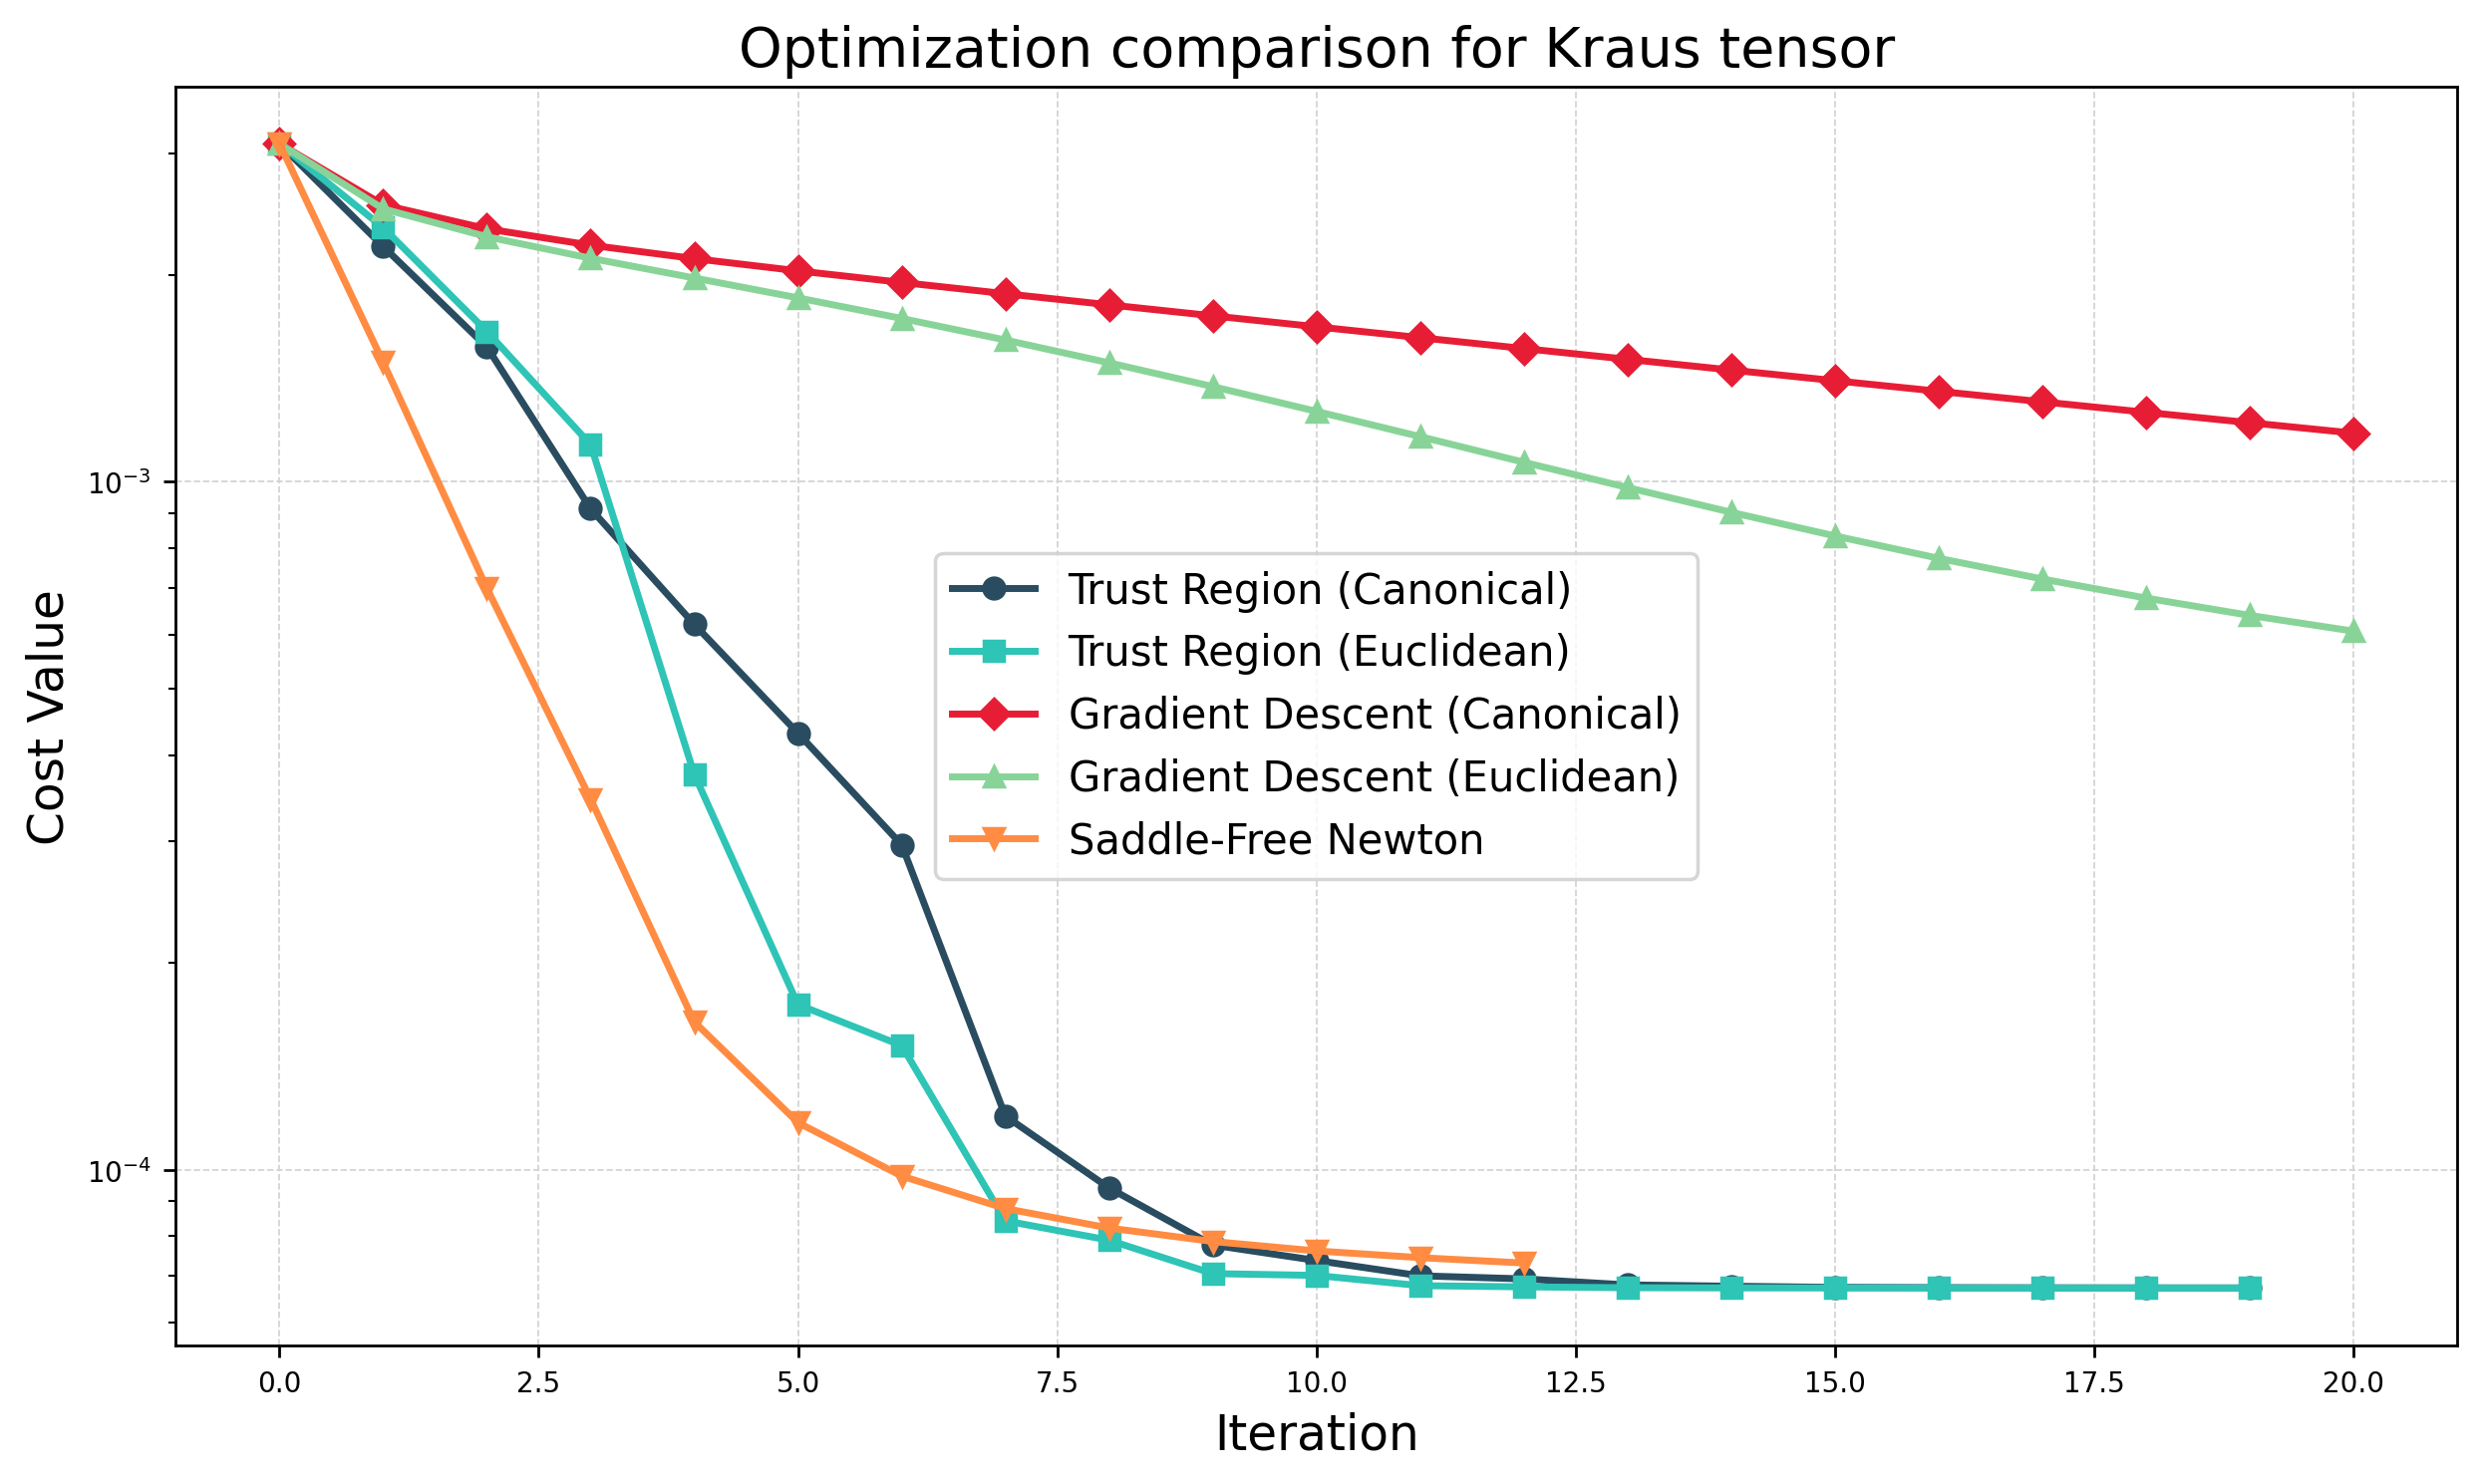

In [312]:
title_kraus = "Optimization comparison for Kraus tensor"
cost_array_all = [cost_kraus_fx_optimized, cost_kraus_fx_optimized_euc, cost_fx_optimized_kraus_gds, cost_fx_optimized_kraus_gds_euclidean, cost_fx_optimized_kraus_sfn_total]
labels_kraus = ["Trust Region (Canonical)", "Trust Region (Euclidean)","Gradient Descent (Canonical)", "Gradient Descent (Euclidean)", "Saddle-Free Newton"]
plot_cost_function(cost_array=cost_array_all, title=title_kraus, labels=labels_kraus)

# Time performance (Kraus)

In [321]:
# Time the performance of one SFN iteration.
%timeit -r2 -n2 update_kraus_via_saddle_free_newton(kraus_tensor=kraus_tensor_init_jax, **cost_fn_kwargs_kraus)

2min 4s ± 493 ms per loop (mean ± std. dev. of 2 runs, 2 loops each)


In [314]:
# Time the performance of the GDS.
%timeit _update_tensor_via_gradient(operator_type="kraus", kraus_tensor=kraus_tensor_init_jax, verbose=False, **cost_fn_kwargs_kraus)

Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
Using JAX power
441 ms ± 19.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [315]:
gradient_init_kraus = riemannian_gradient_fn(x=x_kraus, cost_fn=cost_fn_kraus, operator_type="kraus", metric=metric)

In [316]:
%timeit riemannian_gradient_fn(x=x_kraus, cost_fn=cost_fn_kraus, operator_type="kraus", metric=metric)

124 ms ± 779 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [317]:
# Time individual elements of the TR algorithm.
%timeit compute_quality_quotient(x=x_kraus, update_direction=gradient_init_kraus, cost_function=cost_fn_kraus, x_next=x_kraus, n=n_kraus, p=p_kraus)

172 ms ± 2.22 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [318]:
%timeit riemannian_hessian_vector_fn(x=x_kraus, tangent_vector=gradient_init_kraus, cost_fn=cost_fn_kraus, operator_type="kraus", metric=metric)

183 ms ± 11.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [319]:
gradient_init_kraus_matrix, x_kraus_matrix = tensors_to_isometries(gradient_init_kraus, x_kraus, operator_type="kraus")

In [320]:
%timeit compute_step_size(z=gradient_init_kraus_matrix, delta=gradient_init_kraus_matrix, x=x_kraus_matrix, radius=radius_init, metric=metric)

1.59 ms ± 21.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [3]:
sfn_kraus = (2*60 + 4, 493e-3)
gds_kraus = (441e-3, 19.5e-3)

tr_times_kraus= [(172e-3, 2.22e-3), (124e-3, 779e-6)]  # (mean, std) for quotient, gradient
tr_main_kraus = average_and_error_of_sum(*tr_times_kraus)
hz_kraus = (183e-3, 11.9e-3)
step_kraus = (1.59e-3, 21.6e-6)
tcg_kraus = average_and_error_of_sum(*[hz_kraus, step_kraus])
# How many times can we repeat the hessian-vec-time until the TR time matches the SFN time?
hz_repeats_kraus = (sfn_kraus[0] - tr_main_kraus[0]) / tcg_kraus[0]
print("Estimated Hz repeats Kraus:", hz_repeats_kraus)
# Assume we perform half of those repeats in average.
hz_repeats_estimation_kraus = hz_repeats_kraus//2
hz_scaled_kraus = average_and_error_times_scalar(tcg_kraus, hz_repeats_estimation_kraus)
# Total estimated time for TR iteration.
tr_total_kraus = average_and_error_of_sum(tr_main_kraus, hz_scaled_kraus)
print(f"Trust Region average time: {tr_total_kraus[0]*1e3:.2f} ms ± {tr_total_kraus[1]*1e3:.2f} ms")

INFO:2025-09-30 10:17:54,032:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-09-30 10:17:54,032 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-09-30 10:17:54,036:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

Estimated Hz repeats Kraus: 670.1554797117936
Trust Region average time: 62133.65 ms ± 3986.51 ms


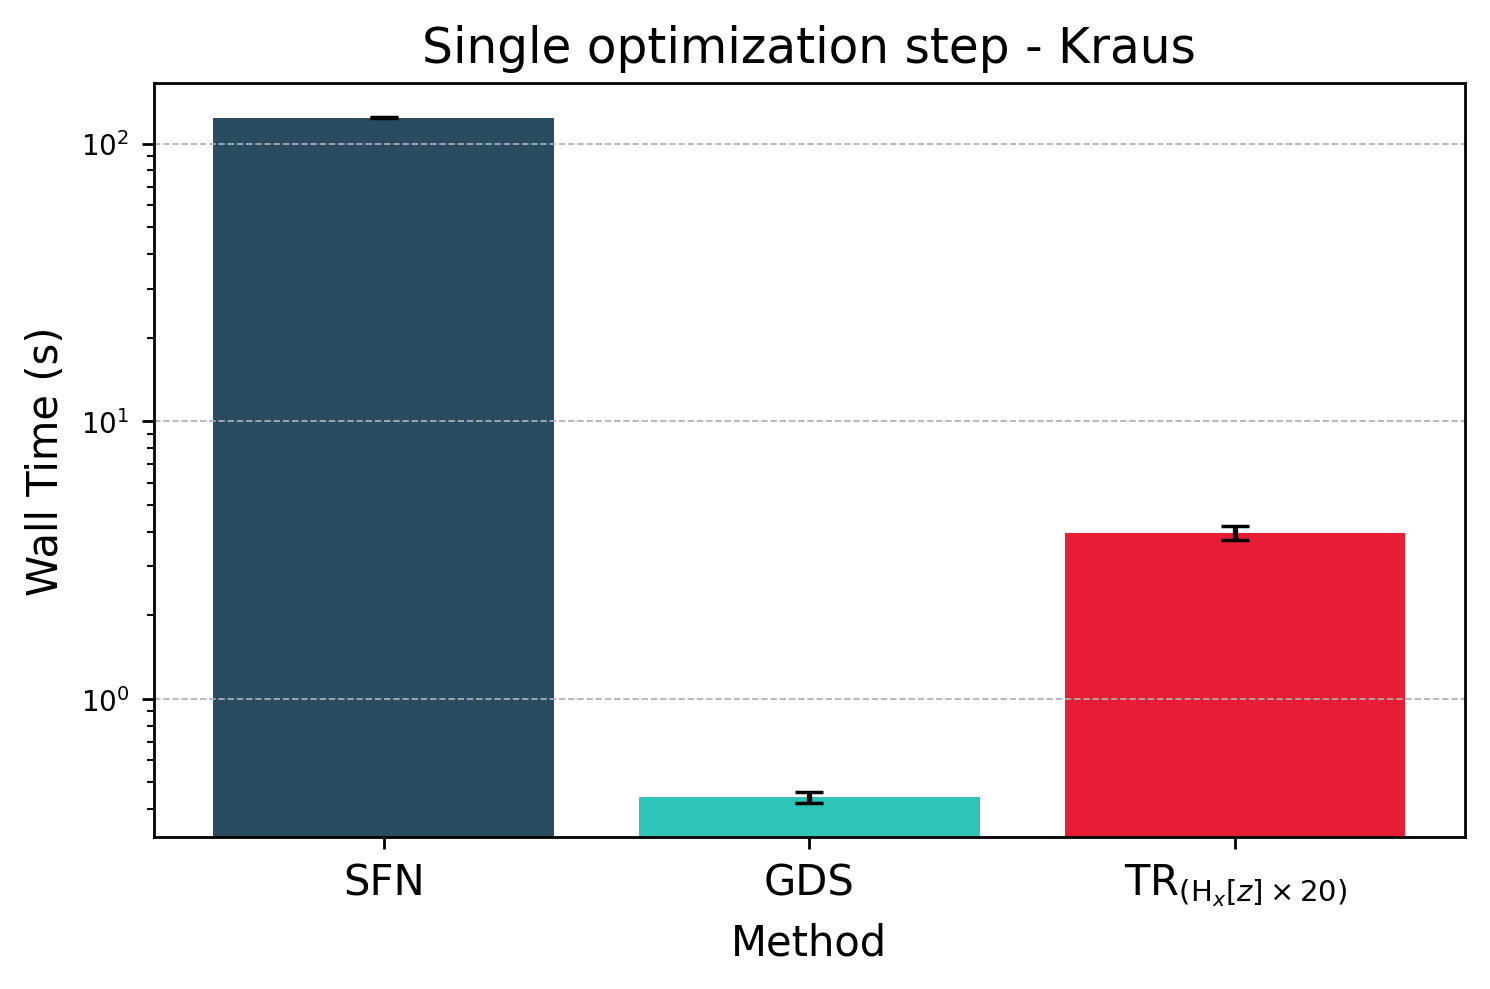

In [7]:
current_num_iters = 20
hz_current_scale_kraus = average_and_error_times_scalar(hz_kraus, current_num_iters) 
tr_current_total_kraus = average_and_error_of_sum(tr_main_kraus, hz_current_scale_kraus)

times_dict_kraus = {
    "SFN": sfn_kraus,  # seconds
    "GDS": gds_kraus,  # seconds
    rf"TR$_{{(\mathsf{{H}}_x[z] \times {current_num_iters:.0f})}}$": tr_current_total_kraus,
    # rf"TR$_{{(\mathsf{{H}}_x[z] \times {hz_repeats_estimation_kraus:.0f})}}$": tr_total_kraus  # seconds
}

plot_bars_with_error(
    data=times_dict_kraus,
    title="Single optimization step - Kraus",
    ylabel="Wall Time (s)",
    xlabel="Method",
    use_log_scale=True,
    bar_spacing=1.0
)

# Visualization TR for [POVM, State, Kraus]

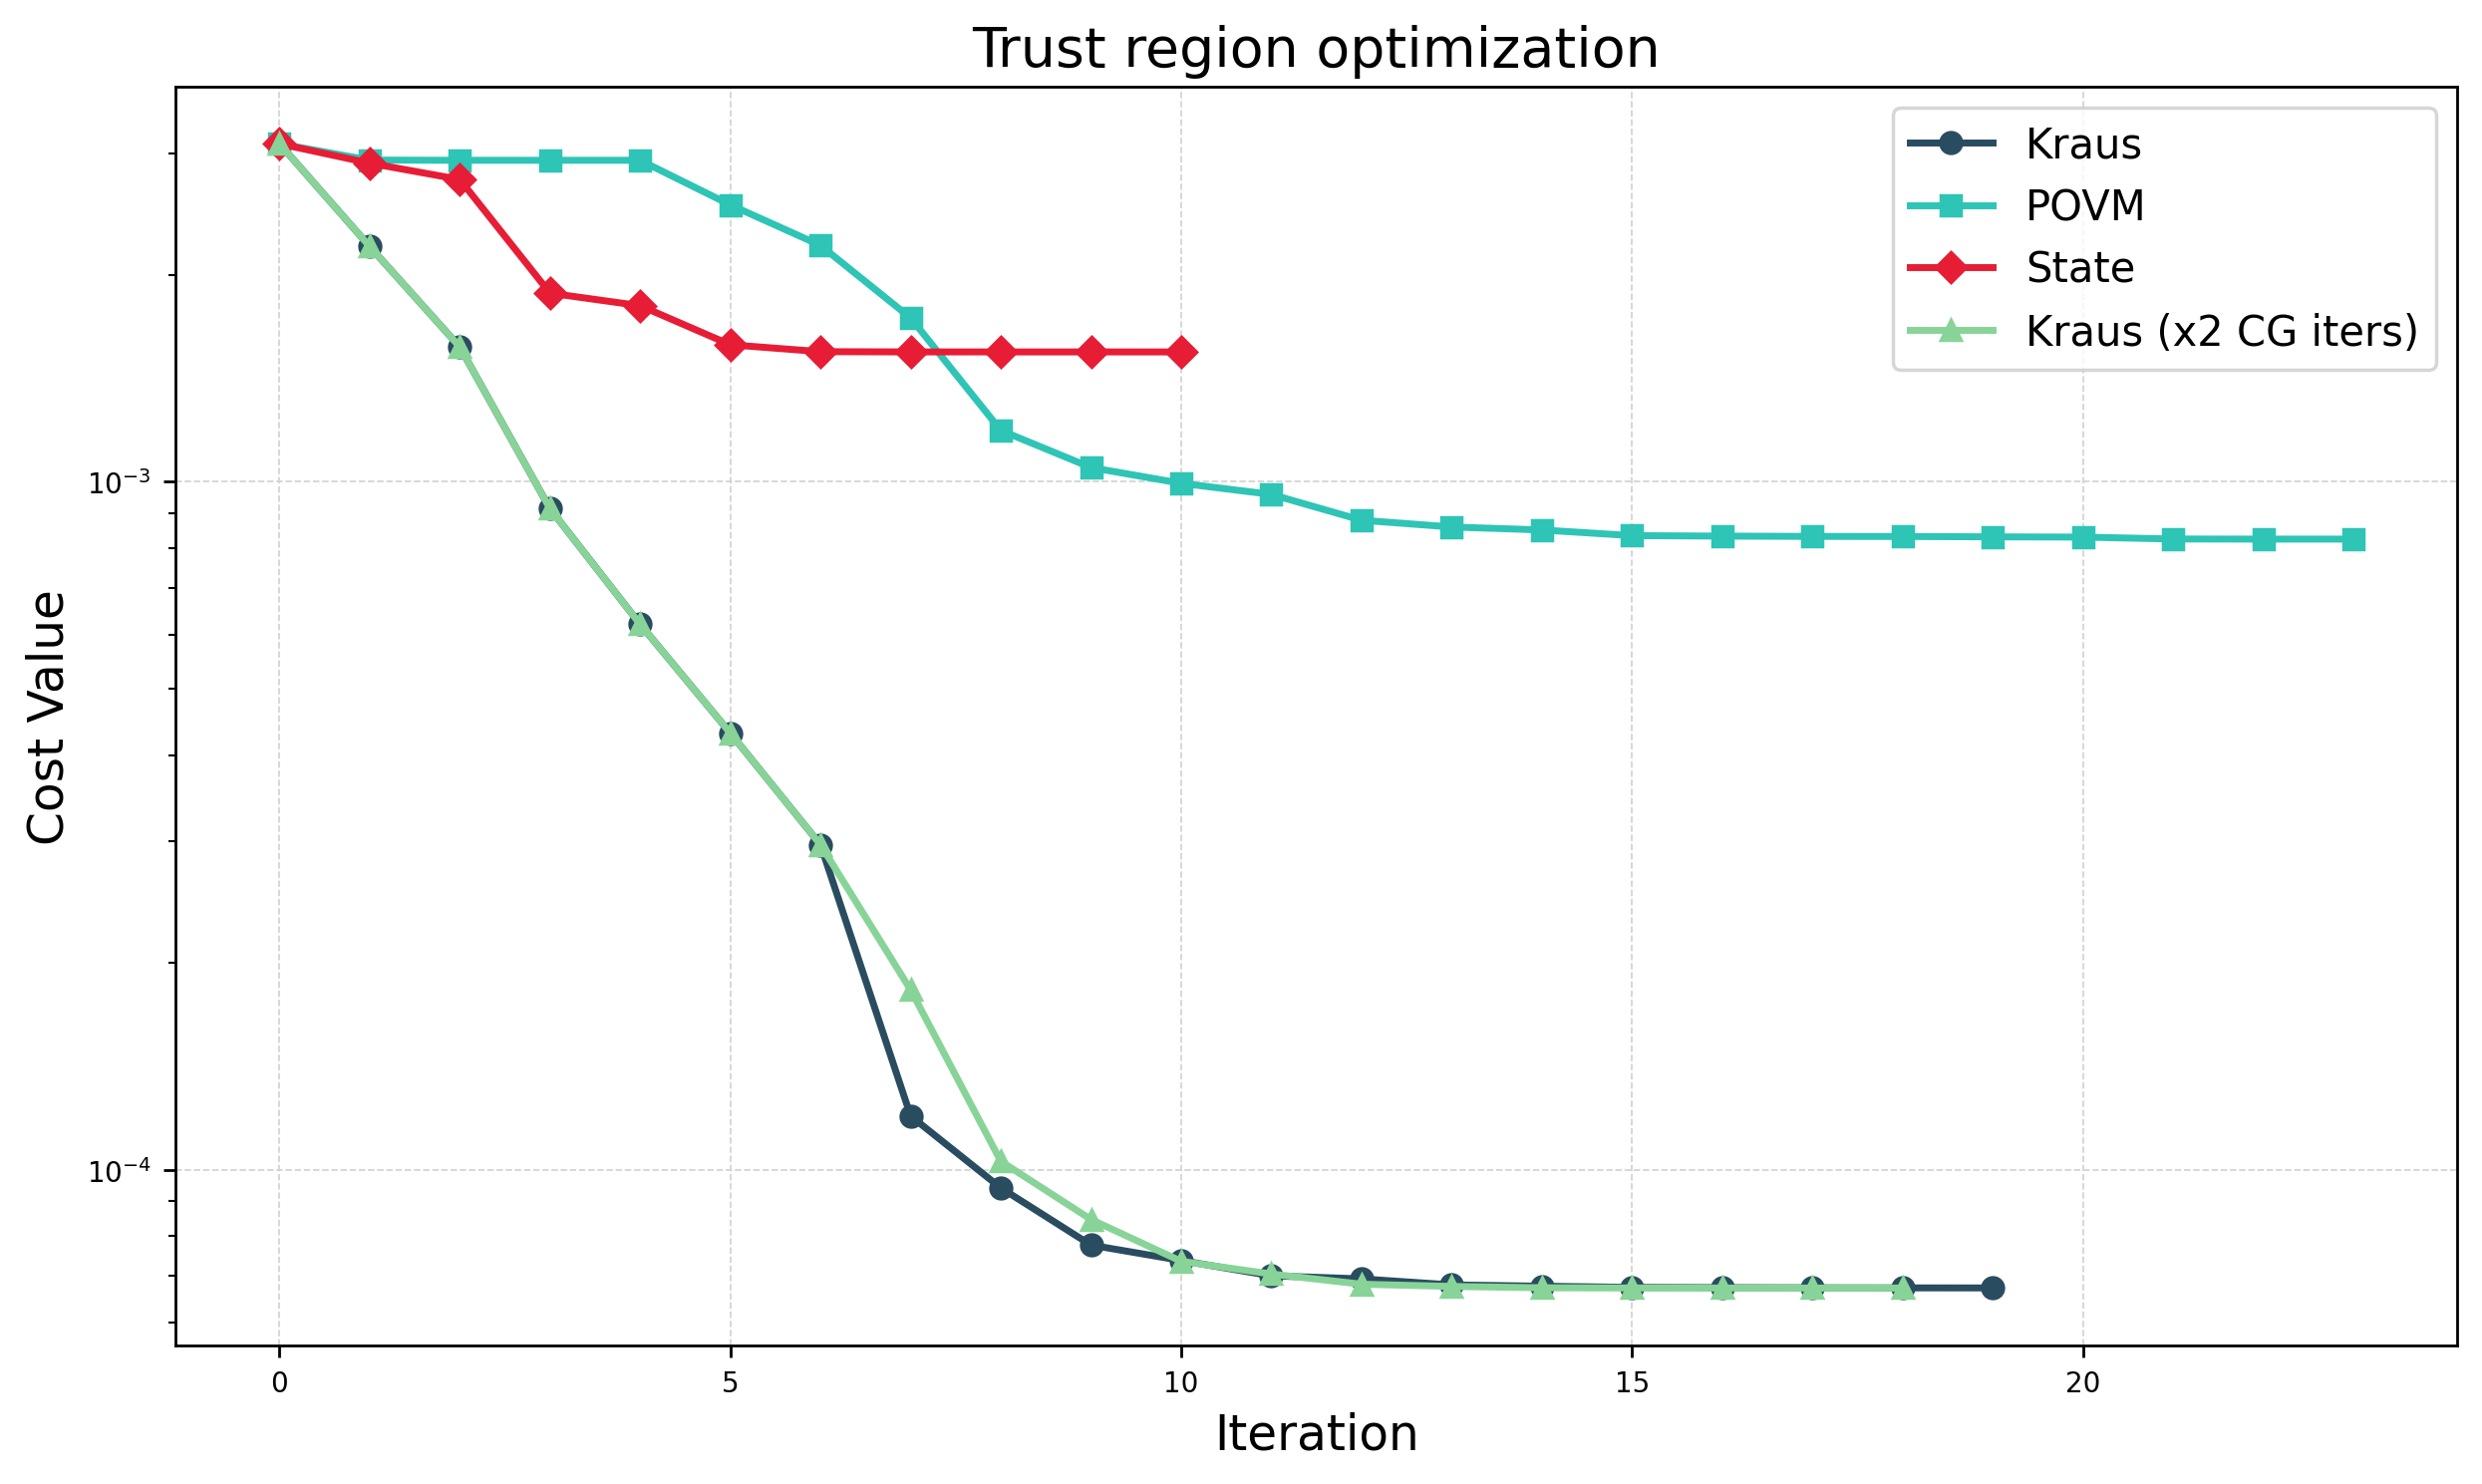

In [264]:
title_all = "Trust region optimization"
cost_array_all = [cost_kraus_fx_optimized, cost_fx_optimized_test, cost_state_fx_optimized, cost_kraus_fx_optimized_2]
labels_all = ["Kraus", "POVM", "State", "Kraus (x2 CG iters)"]
plot_cost_function(cost_array=cost_array_all, title=title_all, labels=labels_all)

# Compute full Hessian

(2, 64, 2, 64)


Text(0.5, 0, 'Index')

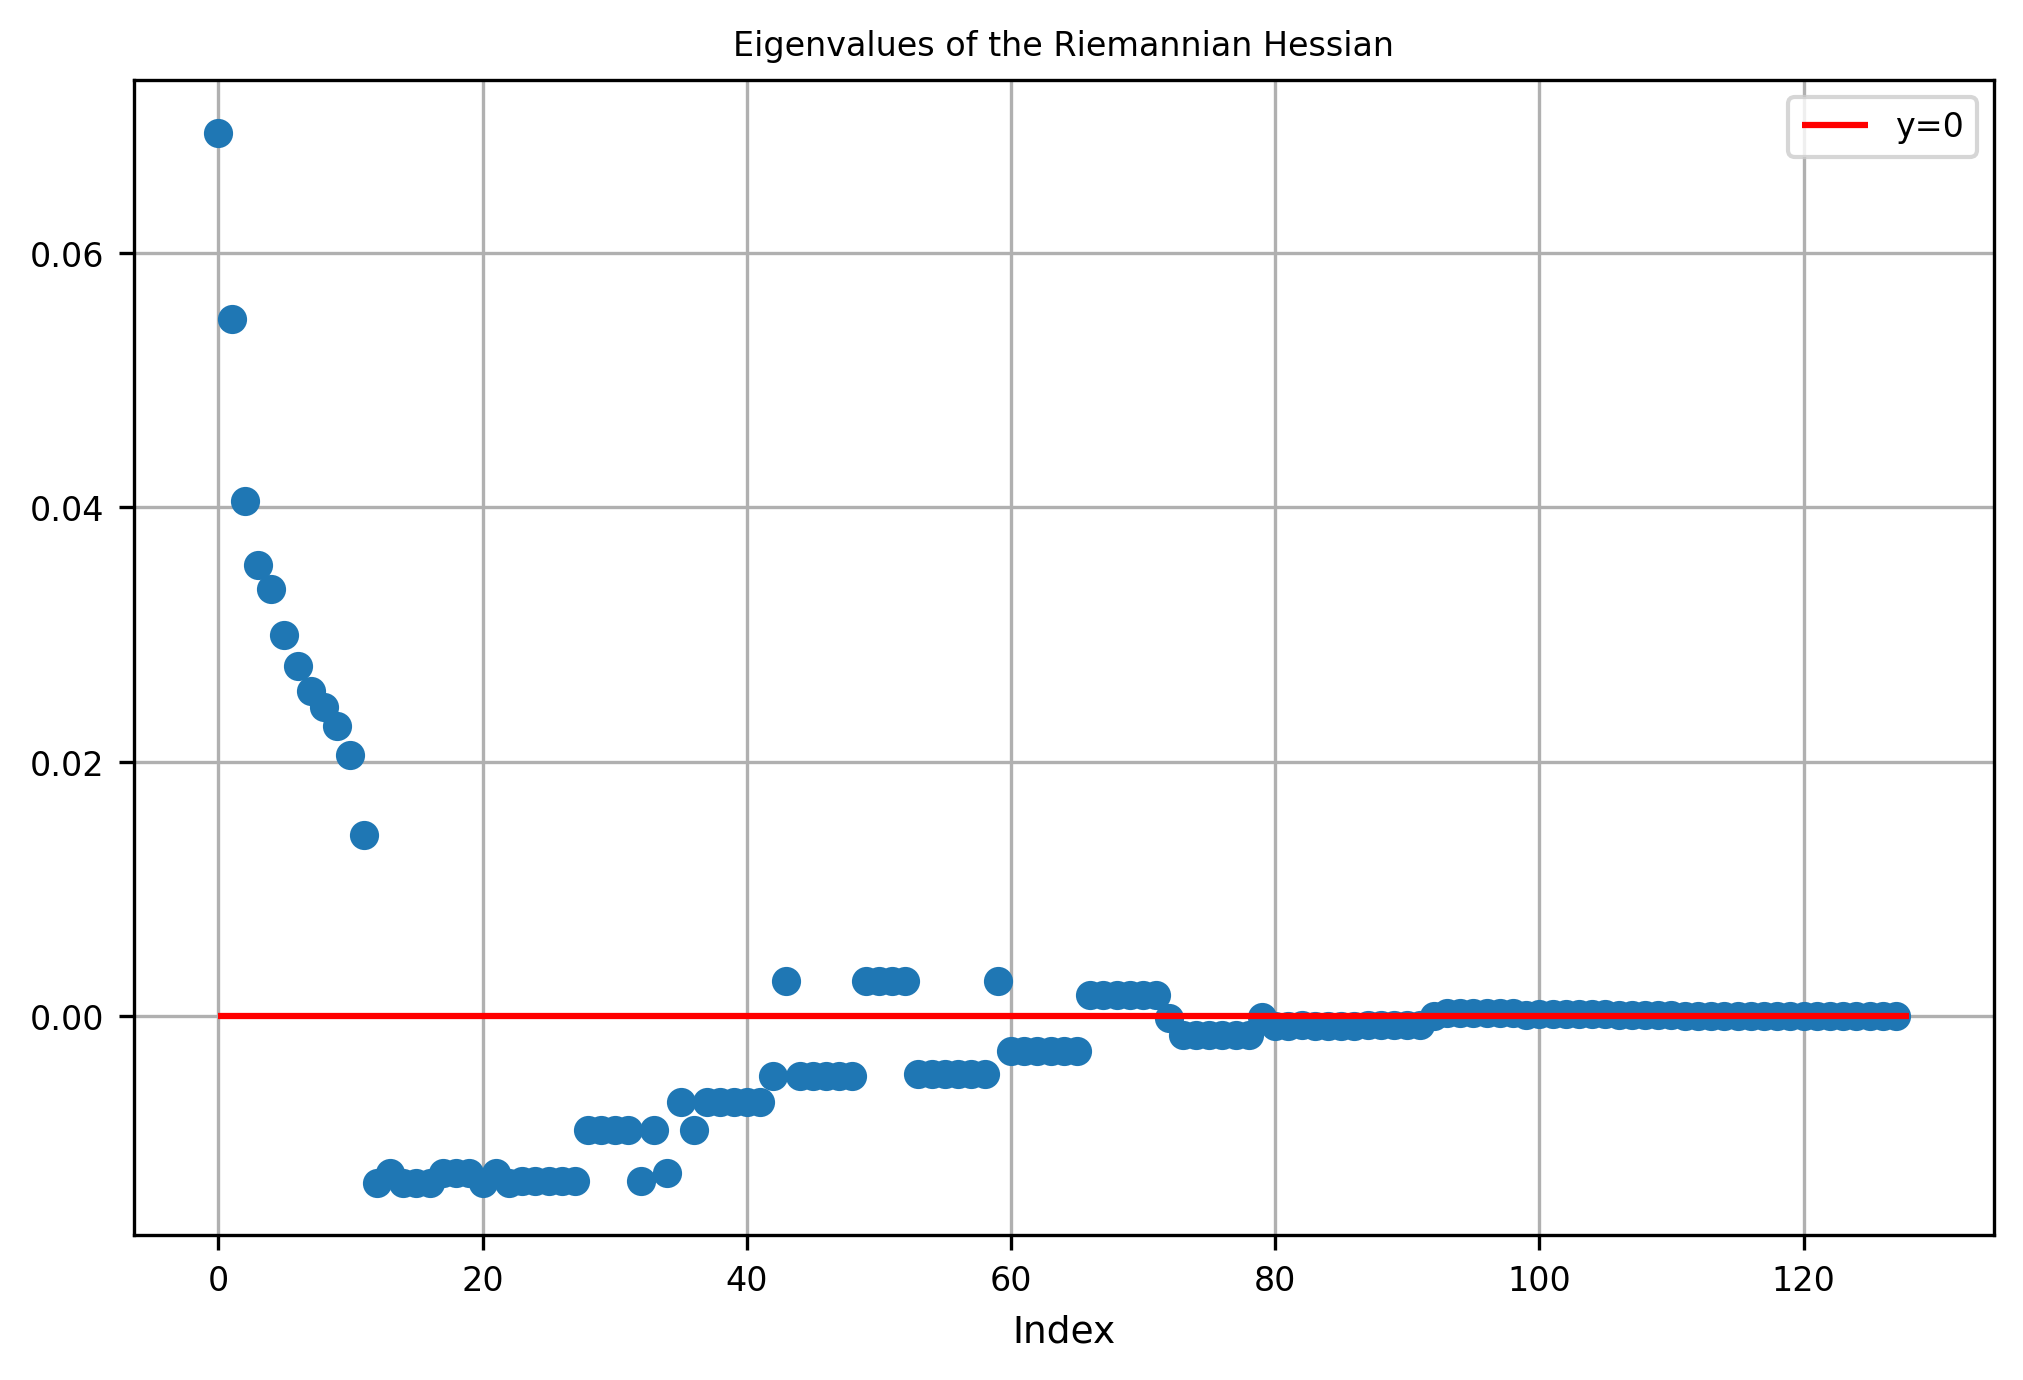

In [82]:
# Compute the full Hessian (using mGST) and its eigenvalues.
rhessian_tensor, rgradient_tensor = riemannian_hessian_povm(
    K=kraus_init_mgst,
    A=povm_psd_init_mgst,
    B=state_psd_init_mgst,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    return_gradient=True
)
print(rhessian_tensor.shape) # 2, n*p, 2, n*p
rhessian_matrix = rhessian_tensor.reshape(2 * n * p, 2 * n * p)
eigvals, eigvects = jnp.linalg.eig(rhessian_matrix)
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(jnp.real(eigvals), 'o')
plt.hlines(y=0, xmin=0, xmax=len(eigvals), colors='r', label="y=0")
plt.title('Eigenvalues of the Riemannian Hessian')
plt.grid()
plt.legend()
plt.xlabel('Index')

# Checking conventions for gradient and Hessian-vector product

In [53]:
# Are gradients the same (up to a factor of 2)?
gradient_mgst_matrix = rgradient_tensor[0] # [grad, grad*], shape = (2, n*p)
gradient_mgst_tensor = isometry_to_tensor(gradient_mgst_matrix, gradient_init.shape)
jnp.allclose(2*gradient_mgst_tensor, gradient_init)

Array(True, dtype=bool)

In [ ]:
# Are the Hessian-vector products the same?
z_test = random_tangent_vector(x=x_matrix, n=n, p=p, seed=42)
hz_test_mgst = riemannian_hessian_vector_mgst(2*rhessian_tensor, z_test) # Add the factor of 2 here to see if adding it globally to the Hessian works
hz_test_mgst_tensor = isometry_to_tensor(hz_test_mgst, gradient_init.shape)

z_tensor_test = isometry_to_tensor(z_test, x.shape)
hz_test_jax = rhessian_vector_fn(x=x, tangent_vector=z_tensor_test)

jnp.allclose(hz_test_mgst_tensor, hz_test_jax)

Using JAX power


Array(True, dtype=bool)

In [56]:
# What about with the gradient
hz_test_mgst_2 = riemannian_hessian_vector_mgst(rhessian_tensor, gradient_mgst_matrix)
hz_test_mgst_2_tensor = isometry_to_tensor(hz_test_mgst_2, gradient_init.shape)
hz_test_jax_2 = rhessian_vector_fn(x=x, tangent_vector=gradient_init)

jnp.allclose(4*hz_test_mgst_2_tensor, hz_test_jax_2)

Using JAX power


Array(True, dtype=bool)

**Conclusion**:
- Gradient is the same up to a factor of 2
- Hessian-vector product is the same up to a factor of 2
- Hessian-gradient product (as expected) is the same up to a factor of 4 (2 from gradient, 2 from Hessian-vector product)

# Test Automatic gradient and Hessian-vector functions

In [ ]:
def riemannian_gradient_fn_general(x:Tensor, cost_fn:Callable[[Tensor], Scalar], operator_type: str, metric: str) -> Tensor:
    """Compute the Riemannian gradient of a cost function at a point x.

    Args:
        x: The point at which to evaluate the gradient.
        cost_fn: The cost function to differentiate.

    Returns:
        The Riemannian gradient of the cost function at x.
    """
    # Compute the Euclidean gradient
    gradient_euclidean_jax = automatic_gradient(cost_fn)(x) # 2df/dx

    # Take the adjoint due to JAX convention
    gradient_euclidean = gradient_euclidean_jax.conj() # 2df/dx*
    # Riemannian gradient based on metric
    gradient_stiefel_matrix, _ = euclidean_gradients_to_stiefel(
        gradient_tensor=gradient_euclidean,
        operator_tensor=x, operator_type=operator_type, metric=metric,
    )
    return isometry_to_tensor(gradient_stiefel_matrix, x.shape)

gradient_test_povm = riemannian_gradient_fn_general(x=x, cost_fn=cost_fn_povm, operator_type="povm", metric="canonical")
assert jnp.allclose(gradient_test_povm, gradient_init)

gradient_init_state = riemannian_gradient_fn(kraus_tensor=kraus_tensor_init_jax, povm_psd=povm_psd_init_jax, state_psd=state_psd_init_jax, indices_list=indices_list_2q, prob_matrix=prob_matrix_2q_sampled, operator_type="state",metric=metric)

cost_fn_state = lambda x: cost_function_jax_mps(
    kraus_tensor=kraus_tensor_init_jax,
    state_psd=x,
    povm_psd=povm_psd_init_jax,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    jit=True)

gradient_test_state = riemannian_gradient_fn_general(x=state_psd_init_jax, cost_fn=cost_fn_state, operator_type="state", metric=metric)

jnp.allclose(gradient_test_state, gradient_init_state)

Using JAX power


Array(True, dtype=bool)

In [ ]:
def riemannian_hessian_vector_fn_test(x:Tensor, tangent_vector:Tensor, cost_fn:Callable[[Tensor], Scalar], operator_type:str, metric:str="canonical", return_tensor:bool=True)-> Tensor|Matrix:
    """Compute the Riemannian Hessian-vector product for the POVM tensor using JAX.
    
    NOTE: For the calculation of the Riemannian Hessian-vector product, we should use df/dx*
    as the euclidean derivative as this is the actual gradient. 
    See:
    - Corollary 4.0.1. of An introduction to complex differentials and complex differentiability - Hunger.
        
    Args:
        povm_psd: POVM square-root-factor of shape (num_povm, povm_rank, dim).
        tangent_vector: Tangent vector determining direction of covariant derivative of shape (num_povm, povm_rank, dim).
        metric: The metric to use for the Hessian-vector product. Can be "canonical" or "euclidean".
    """
    rgrad_fn = lambda x: riemannian_gradient_fn_general(x=x, cost_fn=cost_fn, operator_type=operator_type, metric=metric) # Riemannian gradient (from df/dx*)

    rgrad_x_tensor, Drgrad_x_to_z_tensor = hvp(function=rgrad_fn, x=x, z=tangent_vector)

    n, p = get_isometry_dimensions_from_tensor(x, operator_type=operator_type)
    
    rgrad_x_matrix = tensor_to_isometry(rgrad_x_tensor, n, p)
    Drgrad_to_z_matrix = tensor_to_isometry(Drgrad_x_to_z_tensor, n, p)
    x_matrix = tensor_to_isometry(x, n, p)
    tangent_vector_matrix = tensor_to_isometry(tangent_vector, n, p)
    
    rhessian_vector_product_matrix = riemannian_connection(x=x_matrix, w_x=rgrad_x_matrix, z=tangent_vector_matrix, Dw_x_to_z=Drgrad_to_z_matrix, metric=metric)
    
    if return_tensor:
        return isometry_to_tensor(rhessian_vector_product_matrix, x.shape)
    return rhessian_vector_product_matrix

z_random = random_tangent_vector(x_matrix, n=n, p=p, seed=42)
z_random_tensor = isometry_to_tensor(z_random, x.shape)

rhessian_vect_tensor = rhessian_vector_fn(x=x, tangent_vector=z_random_tensor)
rhessian_vect_tensor_test = riemannian_hessian_vector_fn_test(x=x, tangent_vector=z_random_tensor, cost_fn=cost_fn_povm, operator_type="povm", metric=metric)

assert jnp.allclose(rhessian_vect_tensor, rhessian_vect_tensor_test)

n_test, p_test = get_isometry_dimensions_from_tensor(state_psd_init_jax, operator_type="state")
x_state_matrix = tensor_to_isometry(state_psd_init_jax, n=n_test, p=p_test)
z_state = random_tangent_vector(x_state_matrix, n=n_test, p=p_test, seed=42)
z_state_tensor = isometry_to_tensor(z_state, state_psd_init_jax.shape)

rhessian_vect_state_tensor_test = riemannian_hessian_vector_fn_test(x=state_psd_init_jax, tangent_vector=z_state_tensor, cost_fn=cost_fn_state, operator_type="state", metric=metric)

I test here that the more verstile version that computes the derivatives automatically returns the same results as the ones where the functions where fixed for a specific operator (POVM particularly).

I have tested the state rgrad as well, but not the rhessian-vector product. 

The one for the Kraus should take a minor modification when converting between matrix and tensor.

# Compute the exact solution [FAILED]

The inverse was not well defined

In [86]:
# Compute the exact solution.
rhessian_matrix_scaled = 2*rhessian_matrix
rgradient_vectorized = rgradient_tensor.reshape(-1)
epsilon = 1e-3
# 1st method through numpy inverse
dim_test = rhessian_matrix.shape[0] # 2*n*p
identity = jnp.eye(dim_test)
inverse_matrix = jnp.linalg.inv(rhessian_matrix_scaled + epsilon * identity)
subproblem_solution = ((inverse_matrix @ rgradient_vectorized)[:n * p]).reshape(n, p)

# 2nd method through eigenvalues
eigvals, eigvects = jnp.linalg.eig(rhessian_matrix_scaled)
processed_eigvals = jnp.abs(eigvals) + epsilon # is this correct?
inverse_matrix_2 = eigvects @ jnp.diag(1 / processed_eigvals) @ eigvects.T.conj()
subproblem_solution_2 = ((inverse_matrix_2 @ rgradient_vectorized)[:n * p]).reshape(n, p)

print("Are they the same?", jnp.allclose(subproblem_solution, subproblem_solution_2))

print("Norms: ", jnp.linalg.norm(inverse_matrix - inverse_matrix_2), jnp.linalg.norm(inverse_matrix), jnp.linalg.norm(inverse_matrix_2))

print("Does it invert?",
jnp.allclose(identity, rhessian_matrix_scaled @ inverse_matrix, atol=1e-5), jnp.allclose(identity, rhessian_matrix_scaled @ inverse_matrix_2, atol=1e-5))

Are they the same? False
Norms:  15114.397226771793 10767.642203758509 12416.74687636907
Does it invert? False False


In [ ]:
# 3rd method using penrose inverse
inverse_matrix_3 = jnp.linalg.pinv(rhessian_matrix_scaled)
subproblem_solution_3 = ((inverse_matrix_3 @ rgradient_vectorized)[:n * p]).reshape(n, p)
jnp.allclose(identity, inverse_matrix_3 @ rhessian_matrix_scaled, atol=1e-5)

(Array(False, dtype=bool), Array(0.0497095, dtype=float64))

In [ ]:
possible_solutions = [subproblem_solution, subproblem_solution_2, subproblem_solution_3]
for i, solution in enumerate(possible_solutions):
    print(f"Solution {i+1}")
    print(f"Norm = {jnp.linalg.norm(solution)}")
    print(f"In the tangent space? {is_in_tangent_space(x_matrix, solution)}")

Solution 1
Norm = 0.093718761639177
In the tangent space? False
Solution 2
Norm = 219976.36113354476
In the tangent space? False
Solution 3
Norm = 0.049709498640856636
In the tangent space? False


### Checking how these directions affect cost function:

In [173]:
cost_evaluations = []
for tangent_vector in possible_solutions:
    value = cost_fn_from_updated_povm_direction(tangent_vector)
    cost_evaluations.append(value)
cost_evaluations
    

[Array(0.00293409, dtype=float64),
 Array(0.04972581, dtype=float64),
 Array(0.00291387, dtype=float64)]

### Checking invertibility of matrix

In [107]:
jnp.abs(eigvals)[-20:]

Array([2.16684347e-04, 2.16684347e-04, 2.16684347e-04, 1.17152976e-14,
       1.08007968e-14, 8.41991767e-15, 6.94866757e-15, 2.34686536e-15,
       2.43083814e-15, 7.95457148e-17, 1.94962957e-15, 1.56550564e-15,
       5.31918173e-16, 3.56353577e-16, 3.56487564e-16, 8.12046323e-16,
       9.15560572e-16, 1.18551932e-15, 1.32313600e-15, 1.17643950e-15],      dtype=float64)

In [108]:
1/processed_eigvals[-20:], len(eigvals)

(Array([ 821.90586459,  821.90586459,  821.90586459,  999.99999999,
         999.99999999,  999.99999999,  999.99999999, 1000.        ,
        1000.        , 1000.        , 1000.        , 1000.        ,
        1000.        , 1000.        , 1000.        , 1000.        ,
        1000.        , 1000.        , 1000.        , 1000.        ],      dtype=float64),
 128)

In [122]:
s = np.linalg.svd(rhessian_matrix_scaled, compute_uv=False)
print("singular values (largest..smallest):", s[0], "...", s[-1])
threshold = 1/2.2e-16
condition_number = s[0]/s[-1]
print(f"cond: {condition_number}, above threshold? {condition_number > threshold}")

singular values (largest..smallest): 0.13944822637467702 ... 4.0182774164254497e-17
cond: 3470348408615510.0, above threshold? False
